# Notebook 5 — Efecto de la explotación sobre las lesiones de TB
### Análisis descriptivo y estadístico (sin modelos)

**Pregunta de investigación:** ¿Difiere la prevalencia, la gravedad y el patrón de las
lesiones tuberculosas entre las cuatro explotaciones estudiadas?

| Variable de lesión | Tipo | Test principal |
|---|---|---|
| `Lesiones_TB` | Binaria (0/1) | Chi-cuadrado / Fisher exacto + IC Wilson |
| `Score_lesional` | Ordinal (0–5) | Kruskal-Wallis + Dunn post-hoc |
| `Patron_lesiones` | Binaria (0=focal, 1=generalizado) — solo TB+ | Fisher exacto |
| `IDTC` | Continua (≥0) | Kruskal-Wallis + Dunn post-hoc |

> **Enfoque exclusivamente descriptivo:** se reportan prevalencias, medianas [IQR],
> intervalos de confianza y p-valores de tests no paramétricos. No se ajustan modelos
> predictivos ni se controlan covariables.

## 1. Setup e importaciones

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import (
    kruskal, chi2_contingency, fisher_exact, mannwhitneyu, spearmanr
)
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from itertools import combinations
import tb_utils as tb

PALETTE = tb.set_plot_style()
tb.set_seeds(tb.SEED)

DATA = "../BD.csv"
df = tb.clean(tb.load_raw(DATA))

EXPLOTS = sorted(df[tb.GROUP_COL].unique())
EXPL_COLORS = dict(zip(EXPLOTS, PALETTE[:len(EXPLOTS)]))

print(f"Dataset: n={len(df)}, explotaciones={EXPLOTS}")
print(f"Prevalencia global Lesiones_TB: {df['Lesiones_TB'].mean():.3f}")

Dataset: n=106, explotaciones=['VA32D', 'VC30D', 'VC94C', 'WZ72B']
Prevalencia global Lesiones_TB: 0.613


## 2. Resumen general por explotación

In [2]:
rows = []
for granja in EXPLOTS:
    g = df[df[tb.GROUP_COL] == granja]
    n = len(g)
    n_pos = int(g["Lesiones_TB"].sum())
    prev = n_pos / n
    ci_lo, ci_hi = proportion_confint(n_pos, n, alpha=0.05, method="wilson")
    sl_med = g["Score_lesional"].median()
    sl_q1  = g["Score_lesional"].quantile(0.25)
    sl_q3  = g["Score_lesional"].quantile(0.75)
    idtc_med = g["IDTC"].median()
    idtc_q1  = g["IDTC"].quantile(0.25)
    idtc_q3  = g["IDTC"].quantile(0.75)
    rows.append({
        "Explotación": granja,
        "n": n,
        "TB+ (n)": n_pos,
        "Prevalencia": f"{prev:.1%}",
        "IC 95% (Wilson)": f"[{ci_lo:.1%}, {ci_hi:.1%}]",
        "Score (med [IQR])": f"{sl_med:.1f} [{sl_q1:.1f}–{sl_q3:.1f}]",
        "IDTC (med [IQR])": f"{idtc_med:.1f} [{idtc_q1:.1f}–{idtc_q3:.1f}]",
    })

overview = pd.DataFrame(rows)
print("Tabla resumen general por explotación:")
display(overview)

Tabla resumen general por explotación:


,Explotación,n,TB+ (n),Prevalencia,IC 95% (Wilson),Score (med [IQR]),IDTC (med [IQR])
0,VA32D,21,8,38.1%,"[20.8%, 59.1%]",0.0 [0.0–2.0],13.0 [10.0–17.0]
1,VC30D,55,32,58.2%,"[45.0%, 70.3%]",1.0 [0.0–2.0],10.0 [6.0–13.5]
2,VC94C,16,15,93.8%,"[71.7%, 98.9%]",5.0 [5.0–5.0],7.0 [5.0–10.2]
3,WZ72B,14,10,71.4%,"[45.4%, 88.3%]",1.0 [0.2–1.0],11.5 [9.0–14.0]


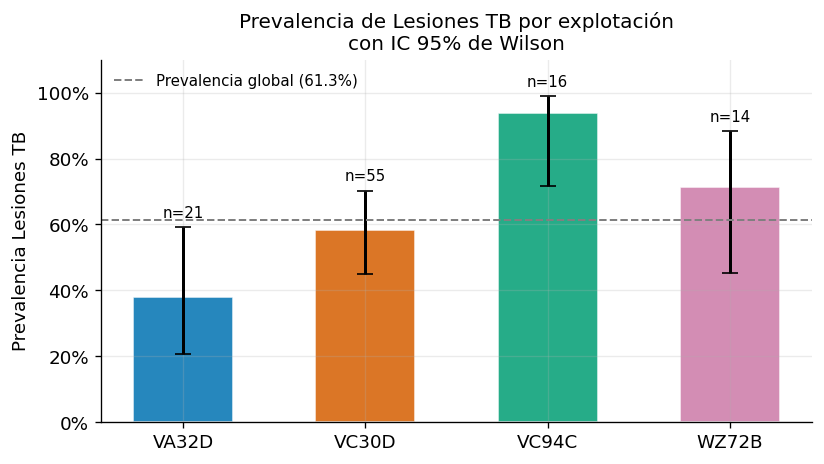

In [3]:
# Figura de prevalencias con IC
prevs, ci_los, ci_his, ns = [], [], [], []
for granja in EXPLOTS:
    g = df[df[tb.GROUP_COL] == granja]
    n = len(g); n_pos = int(g["Lesiones_TB"].sum())
    lo, hi = proportion_confint(n_pos, n, alpha=0.05, method="wilson")
    prevs.append(n_pos / n); ci_los.append(lo); ci_his.append(hi); ns.append(n)

fig, ax = plt.subplots(figsize=(7, 4))
colors = [EXPL_COLORS[g] for g in EXPLOTS]
bars = ax.bar(EXPLOTS, prevs, color=colors, alpha=0.85, edgecolor="white", width=0.55)
for i, (lo, hi, p, n) in enumerate(zip(ci_los, ci_his, prevs, ns)):
    ax.errorbar(EXPLOTS[i], p, yerr=[[p - lo], [hi - p]],
                fmt="none", color="black", capsize=5, lw=1.8)
    ax.text(i, hi + 0.03, f"n={n}", ha="center", fontsize=9)

prev_global = df["Lesiones_TB"].mean()
ax.axhline(prev_global, ls="--", color="grey", lw=1.2, label=f"Prevalencia global ({prev_global:.1%})")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Prevalencia Lesiones TB")
ax.set_title("Prevalencia de Lesiones TB por explotación\ncon IC 95% de Wilson")
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.savefig("figures/fig_05_prevalencia_por_explotacion.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Lesiones_TB vs Explotación — test de homogeneidad

Pregunta: ¿son las prevalencias de lesión TB estadísticamente distintas entre explotaciones?

- **Test global:** Chi-cuadrado de Pearson (tabla 4×2) si todos los esperados ≥ 5,
  sino test exacto de Freeman-Halton.
- **Comparaciones pareadas:** test exacto de Fisher con corrección de Bonferroni.

In [4]:
# Tabla de contingencia 4×2
cont_tb = pd.crosstab(df[tb.GROUP_COL], df["Lesiones_TB"])
cont_tb.columns = ["TB−", "TB+"]
print("Tabla de contingencia Expl × Lesiones_TB:")
display(cont_tb)

chi2, p_chi2, dof, expected = chi2_contingency(cont_tb)
min_expected = expected.min()
print(f"\nChi-cuadrado (global):")
print(f"  χ²({dof}) = {chi2:.3f}, p = {p_chi2:.4f}")
print(f"  Frecuencias esperadas mínimas = {min_expected:.2f}")
if min_expected < 5:
    print("  ⚠ Alguna celda esperada < 5 — interpretar con cautela.")
else:
    print("  ✓ Todas las celdas esperadas ≥ 5.")

Tabla de contingencia Expl × Lesiones_TB:


,TB−,TB+
Expl,,
VA32D,13,8
VC30D,23,32
VC94C,1,15
WZ72B,4,10



Chi-cuadrado (global):
  χ²(3) = 12.702, p = 0.0053
  Frecuencias esperadas mínimas = 5.42
  ✓ Todas las celdas esperadas ≥ 5.


In [5]:
# Comparaciones pareadas con Fisher exacto + corrección de Bonferroni
pairs = list(combinations(EXPLOTS, 2))
n_tests = len(pairs)
rows_pw = []
for a, b in pairs:
    sub = df[df[tb.GROUP_COL].isin([a, b])]
    ct = pd.crosstab(sub[tb.GROUP_COL], sub["Lesiones_TB"]).reindex([a, b])
    # Asegurar columnas 0 y 1
    for col in [0, 1]:
        if col not in ct.columns:
            ct[col] = 0
    ct = ct[[0, 1]]
    table_2x2 = ct.values
    _, p = fisher_exact(table_2x2)
    p_bonf = min(p * n_tests, 1.0)
    prev_a = df[df[tb.GROUP_COL] == a]["Lesiones_TB"].mean()
    prev_b = df[df[tb.GROUP_COL] == b]["Lesiones_TB"].mean()
    rows_pw.append({
        "Expl A": a, "Prev A": f"{prev_a:.1%}",
        "Expl B": b, "Prev B": f"{prev_b:.1%}",
        "p (Fisher)": round(p, 4),
        "p (Bonferroni)": round(p_bonf, 4),
        "Sig.": "*" if p_bonf < 0.05 else "",
    })

pw_df = pd.DataFrame(rows_pw)
print(f"Comparaciones pareadas (Fisher exacto, Bonferroni n={n_tests}):")
display(pw_df)

Comparaciones pareadas (Fisher exacto, Bonferroni n=6):


,Expl A,Prev A,Expl B,Prev B,p (Fisher),p (Bonferroni),Sig.
0,VA32D,38.1%,VC30D,58.2%,0.1320,0.7921,
1,VA32D,38.1%,VC94C,93.8%,0.0006,0.0037,*
2,VA32D,38.1%,WZ72B,71.4%,0.0858,0.5148,
3,VC30D,58.2%,VC94C,93.8%,0.0075,0.0448,*
4,VC30D,58.2%,WZ72B,71.4%,0.5412,1.0000,
5,VC94C,93.8%,WZ72B,71.4%,0.1571,0.9425,


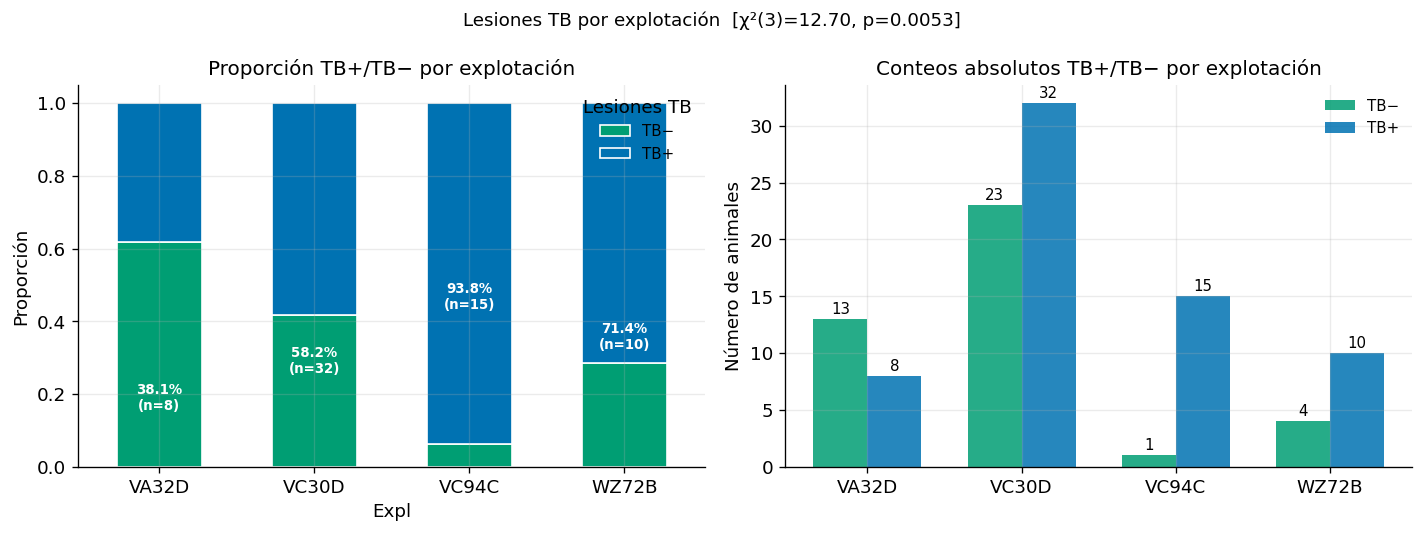

In [6]:
# Gráfico de barras apiladas (proporcional)
prop_df = cont_tb.div(cont_tb.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Barras apiladas proporcionales
ax = axes[0]
prop_df.plot(kind="bar", stacked=True, ax=ax,
             color=[PALETTE[2], PALETTE[0]], edgecolor="white", width=0.55)
ax.set_ylabel("Proporción")
ax.set_title("Proporción TB+/TB− por explotación")
ax.set_xticklabels(EXPLOTS, rotation=0)
ax.legend(["TB−", "TB+"], title="Lesiones TB", fontsize=9)
for i, granja in enumerate(EXPLOTS):
    p_pos = prop_df.loc[granja, "TB+"]
    n = cont_tb.loc[granja].sum()
    ax.text(i, p_pos / 2, f"{p_pos:.1%}\n(n={cont_tb.loc[granja,'TB+']})",
            ha="center", va="center", fontsize=8, color="white", fontweight="bold")

# Conteos absolutos
ax2 = axes[1]
x = np.arange(len(EXPLOTS))
width = 0.35
b1 = ax2.bar(x - width/2, cont_tb["TB−"], width, label="TB−", color=PALETTE[2], alpha=0.85)
b2 = ax2.bar(x + width/2, cont_tb["TB+"], width, label="TB+", color=PALETTE[0], alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(EXPLOTS)
ax2.set_ylabel("Número de animales")
ax2.set_title("Conteos absolutos TB+/TB− por explotación")
ax2.legend(fontsize=9)
for bar in [*b1, *b2]:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.2, str(int(h)),
             ha="center", va="bottom", fontsize=9)

plt.suptitle(f"Lesiones TB por explotación  [χ²({dof})={chi2:.2f}, p={p_chi2:.4f}]", fontsize=11)
plt.tight_layout()
plt.savefig("figures/fig_05_lesiones_tb_por_explotacion.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Score lesional por explotación

El score lesional es ordinal (0–5). Se usa Kruskal-Wallis (no paramétrico) y,
si es significativo, test de Dunn con corrección de Bonferroni para identificar
qué pares de explotaciones difieren.

> Nota: el score es 0 en animales sin lesión (TB−), por lo que el análisis global
> refleja tanto la prevalencia como la gravedad. Se muestra también restringido
> a animales TB+ para separar ambos efectos.

In [7]:
# Descriptivos del score por explotación (todos los animales)
score_desc = df.groupby(tb.GROUP_COL)["Score_lesional"].describe(
    percentiles=[0.25, 0.5, 0.75]
).round(2)
score_desc["median"] = df.groupby(tb.GROUP_COL)["Score_lesional"].median().round(2)
print("Descriptivos Score lesional por explotación (todos los animales):")
display(score_desc)

# Kruskal-Wallis global
groups_score = [df[df[tb.GROUP_COL] == g]["Score_lesional"].dropna().values for g in EXPLOTS]
H, p_kw = kruskal(*groups_score)
print(f"\nKruskal-Wallis (Score lesional ~ Explotación):")
print(f"  H = {H:.3f}, p = {p_kw:.4f}")
if p_kw < 0.05:
    print("  → Diferencias significativas entre explotaciones.")
else:
    print("  → No se detectan diferencias significativas (α=0.05).")

Descriptivos Score lesional por explotación (todos los animales):


,count,mean,std,min,25%,50%,75%,max,median
Expl,,,,,,,,,
VA32D,21.0,0.76,1.00,0.0,0.00,0.0,2.0,2.0,0.0
VC30D,55.0,1.49,1.76,0.0,0.00,1.0,2.0,5.0,1.0
VC94C,16.0,4.31,1.54,0.0,5.00,5.0,5.0,5.0,5.0
WZ72B,14.0,0.71,0.47,0.0,0.25,1.0,1.0,1.0,1.0



Kruskal-Wallis (Score lesional ~ Explotación):
  H = 29.988, p = 0.0000
  → Diferencias significativas entre explotaciones.


In [8]:
# Test de Dunn post-hoc (todos los animales)
dunn_rows = []
pairs = list(combinations(EXPLOTS, 2))
n_pairs = len(pairs)
for a, b in pairs:
    g_a = df[df[tb.GROUP_COL] == a]["Score_lesional"].dropna().values
    g_b = df[df[tb.GROUP_COL] == b]["Score_lesional"].dropna().values
    _, p_mw = mannwhitneyu(g_a, g_b, alternative="two-sided")
    p_bonf = min(p_mw * n_pairs, 1.0)
    med_a = np.median(g_a); med_b = np.median(g_b)
    dunn_rows.append({
        "Expl A": a, "Med A": med_a,
        "Expl B": b, "Med B": med_b,
        "p (MW)": round(p_mw, 4),
        "p (Bonferroni)": round(p_bonf, 4),
        "Sig.": "*" if p_bonf < 0.05 else "",
    })

dunn_df = pd.DataFrame(dunn_rows)
print(f"Comparaciones pareadas Mann-Whitney U + Bonferroni (n={n_pairs}):")
display(dunn_df)

Comparaciones pareadas Mann-Whitney U + Bonferroni (n=6):


,Expl A,Med A,Expl B,Med B,p (MW),p (Bonferroni),Sig.
0,VA32D,0.0,VC30D,1.0,0.1529,0.9176,
1,VA32D,0.0,VC94C,5.0,0.0000,0.0000,*
2,VA32D,0.0,WZ72B,1.0,0.7563,1.0000,
3,VC30D,1.0,VC94C,5.0,0.0000,0.0000,*
4,VC30D,1.0,WZ72B,1.0,0.4940,1.0000,
5,VC94C,5.0,WZ72B,1.0,0.0000,0.0001,*


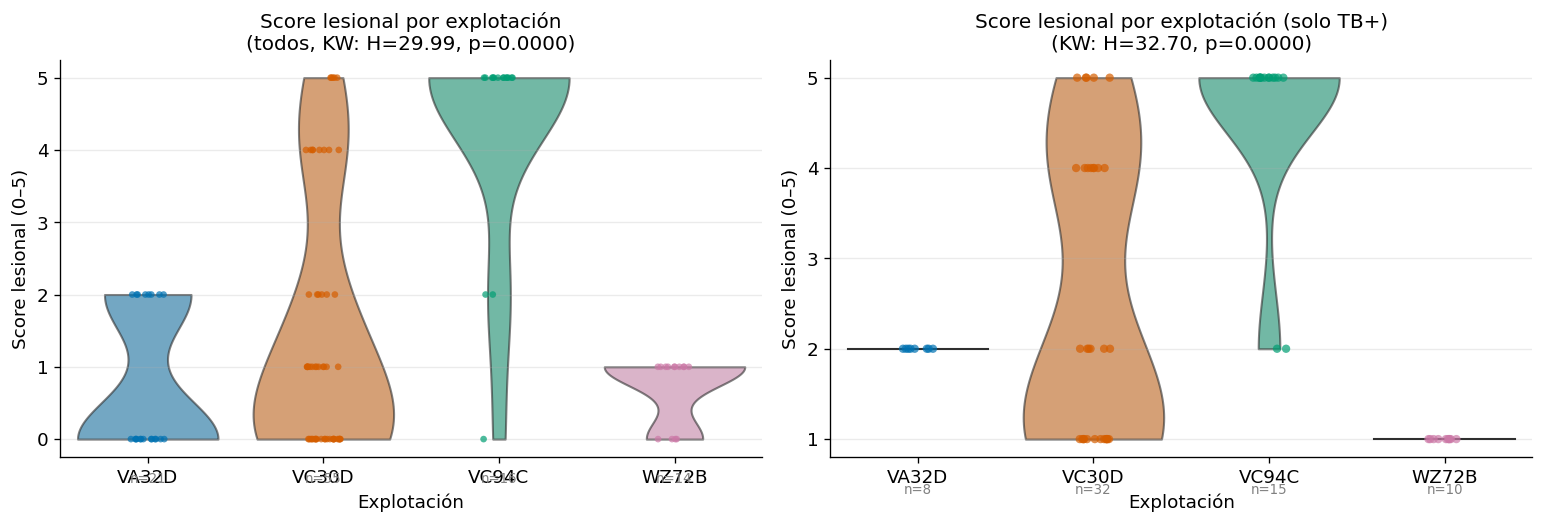

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Violin + strip — todos los animales
ax = axes[0]
sns.violinplot(data=df, x=tb.GROUP_COL, y="Score_lesional", order=EXPLOTS,
               palette=EXPL_COLORS, inner=None, ax=ax, alpha=0.6, cut=0)
sns.stripplot(data=df, x=tb.GROUP_COL, y="Score_lesional", order=EXPLOTS,
              palette=EXPL_COLORS, jitter=True, alpha=0.7, size=4, ax=ax)
ax.set_title(f"Score lesional por explotación\n(todos, KW: H={H:.2f}, p={p_kw:.4f})")
ax.set_xlabel("Explotación"); ax.set_ylabel("Score lesional (0–5)")
ax.set_yticks(range(6))

# Solo TB+ para aislar gravedad
df_pos = df[df["Lesiones_TB"] == 1].copy()
groups_pos = [df_pos[df_pos[tb.GROUP_COL] == g]["Score_lesional"].dropna().values for g in EXPLOTS]
# Excluir grupos con menos de 2 observaciones
valid_explots = [g for g, gr in zip(EXPLOTS, groups_pos) if len(gr) >= 2]
valid_groups  = [gr for gr in groups_pos if len(gr) >= 2]
if len(valid_groups) >= 2:
    H_pos, p_pos = kruskal(*valid_groups)
    title_pos = f"Score lesional por explotación (solo TB+)\n(KW: H={H_pos:.2f}, p={p_pos:.4f})"
else:
    H_pos, p_pos = None, None
    title_pos = "Score lesional por explotación (solo TB+)"

ax2 = axes[1]
sns.violinplot(data=df_pos, x=tb.GROUP_COL, y="Score_lesional", order=EXPLOTS,
               palette=EXPL_COLORS, inner=None, ax=ax2, alpha=0.6, cut=0)
sns.stripplot(data=df_pos, x=tb.GROUP_COL, y="Score_lesional", order=EXPLOTS,
              palette=EXPL_COLORS, jitter=True, alpha=0.7, size=5, ax=ax2)
ax2.set_title(title_pos)
ax2.set_xlabel("Explotación"); ax2.set_ylabel("Score lesional (0–5)")
ax2.set_yticks(range(1, 6))

# Anotar n por grupo en ambos paneles
for i, granja in enumerate(EXPLOTS):
    n_all = (df[tb.GROUP_COL] == granja).sum()
    n_pos2 = (df_pos[tb.GROUP_COL] == granja).sum()
    axes[0].text(i, -0.6, f"n={n_all}", ha="center", fontsize=8, color="grey")
    axes[1].text(i, 0.4, f"n={n_pos2}", ha="center", fontsize=8, color="grey")

plt.tight_layout()
plt.savefig("figures/fig_05_score_lesional_por_explotacion.png", dpi=150, bbox_inches="tight")
plt.show()

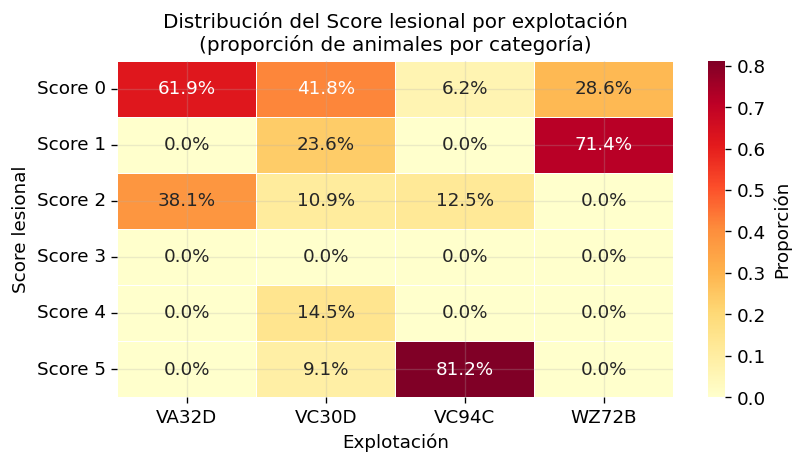

In [10]:
# Distribución de frecuencias del score por explotación (heatmap de proporciones)
scores_all = range(0, 6)
heat_data = pd.DataFrame(
    {granja: [round((df[df[tb.GROUP_COL] == granja]["Score_lesional"] == s).mean(), 3)
              for s in scores_all]
     for granja in EXPLOTS},
    index=[f"Score {s}" for s in scores_all]
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(heat_data, annot=True, fmt=".1%", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Proporción"})
ax.set_title("Distribución del Score lesional por explotación\n(proporción de animales por categoría)")
ax.set_ylabel("Score lesional"); ax.set_xlabel("Explotación")
plt.tight_layout()
plt.savefig("figures/fig_05_score_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Patrón de lesiones (generalizado vs focal) por explotación

Análisis restringido a animales **TB+** (n con lesión).
`Patron_lesiones`: 0 = lesión focal (nodal única), 1 = lesión generalizada (patrón extendido).

Se usa test exacto de Fisher (o chi-cuadrado si los esperados lo permiten) dado el
número reducido de animales con lesión en algunas explotaciones.

In [11]:
df_pat = df[df["Lesiones_TB"] == 1].copy()

# Tabla de contingencia Expl × Patron_lesiones
cont_pat = pd.crosstab(df_pat[tb.GROUP_COL], df_pat["Patron_lesiones"])
cont_pat.columns = ["Focal (0)", "Generalizado (1)"]
print("Tabla de contingencia Expl × Patrón de lesiones (solo TB+):")
display(cont_pat)

# Test global
chi2_pat, p_chi2_pat, dof_pat, exp_pat = chi2_contingency(cont_pat)
min_exp_pat = exp_pat.min()
print(f"\nChi-cuadrado: χ²({dof_pat}) = {chi2_pat:.3f}, p = {p_chi2_pat:.4f}")
print(f"Frecuencia esperada mínima: {min_exp_pat:.2f}")
if min_exp_pat < 5:
    print("⚠ Esperados < 5 en alguna celda — se recomienda usar Fisher exacto (ver comparaciones pareadas).")

# Proporciones de patrón generalizado por explotación
print("\nProporción patrón generalizado por explotación (entre TB+):")
for granja in EXPLOTS:
    g = df_pat[df_pat[tb.GROUP_COL] == granja]
    n_g = len(g)
    n_gen = int((g["Patron_lesiones"] == 1).sum())
    if n_g > 0:
        lo, hi = proportion_confint(n_gen, n_g, alpha=0.05, method="wilson")
        print(f"  {granja}: {n_gen}/{n_g} = {n_gen/n_g:.1%} [IC95%: {lo:.1%}–{hi:.1%}]")
    else:
        print(f"  {granja}: sin datos TB+")

Tabla de contingencia Expl × Patrón de lesiones (solo TB+):


,Focal (0),Generalizado (1)
Expl,,
VA32D,5,3
VC30D,24,8
VC94C,2,13
WZ72B,10,0



Chi-cuadrado: χ²(3) = 23.745, p = 0.0000
Frecuencia esperada mínima: 2.95
⚠ Esperados < 5 en alguna celda — se recomienda usar Fisher exacto (ver comparaciones pareadas).

Proporción patrón generalizado por explotación (entre TB+):
  VA32D: 3/8 = 37.5% [IC95%: 13.7%–69.4%]
  VC30D: 8/32 = 25.0% [IC95%: 13.3%–42.1%]
  VC94C: 13/15 = 86.7% [IC95%: 62.1%–96.3%]
  WZ72B: 0/10 = 0.0% [IC95%: 0.0%–27.8%]


In [12]:
# Comparaciones pareadas con Fisher exacto (solo pares con datos en ambas clases)
pat_pairs = []
for a, b in combinations(EXPLOTS, 2):
    sub = df_pat[df_pat[tb.GROUP_COL].isin([a, b])]
    ct = pd.crosstab(sub[tb.GROUP_COL], sub["Patron_lesiones"]).reindex([a, b])
    for col in [0, 1]:
        if col not in ct.columns:
            ct[col] = 0
    ct = ct[[0, 1]]
    if ct.shape == (2, 2) and ct.values.sum() >= 4:
        _, p = fisher_exact(ct.values)
        p_bonf = min(p * n_pairs, 1.0)
        n_a = (df_pat[tb.GROUP_COL] == a).sum()
        n_b = (df_pat[tb.GROUP_COL] == b).sum()
        prop_a = (df_pat[df_pat[tb.GROUP_COL] == a]["Patron_lesiones"] == 1).mean()
        prop_b = (df_pat[df_pat[tb.GROUP_COL] == b]["Patron_lesiones"] == 1).mean()
        pat_pairs.append({
            "Expl A": f"{a} ({n_a})", "% Gen. A": f"{prop_a:.1%}",
            "Expl B": f"{b} ({n_b})", "% Gen. B": f"{prop_b:.1%}",
            "p (Fisher)": round(p, 4),
            "p (Bonferroni)": round(p_bonf, 4),
            "Sig.": "*" if p_bonf < 0.05 else "",
        })

if pat_pairs:
    print("Comparaciones pareadas — Patrón generalizado:")
    display(pd.DataFrame(pat_pairs))

Comparaciones pareadas — Patrón generalizado:


,Expl A,% Gen. A,Expl B,% Gen. B,p (Fisher),p (Bonferroni),Sig.
0,VA32D (8),37.5%,VC30D (32),25.0%,0.6603,1.0000,
1,VA32D (8),37.5%,VC94C (15),86.7%,0.0257,0.1544,
2,VA32D (8),37.5%,WZ72B (10),0.0%,0.0686,0.4118,
3,VC30D (32),25.0%,VC94C (15),86.7%,0.0001,0.0006,*
4,VC30D (32),25.0%,WZ72B (10),0.0%,0.1646,0.9876,
5,VC94C (15),86.7%,WZ72B (10),0.0%,0.0000,0.0001,*


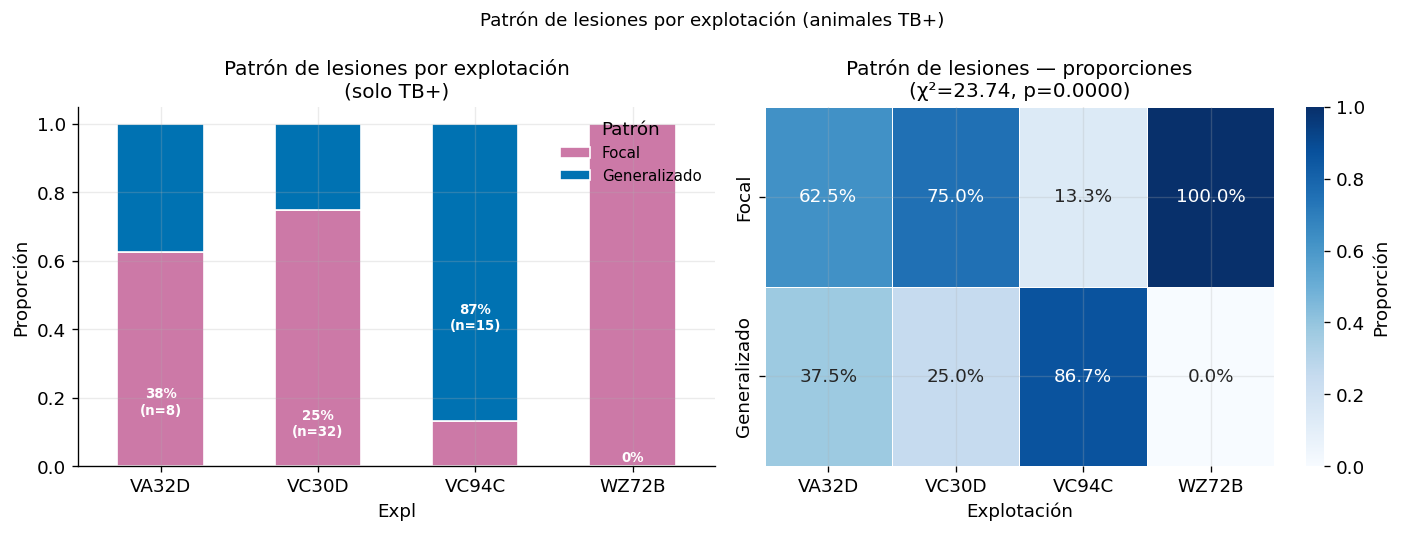

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Barras apiladas proporcionales (patrón)
pat_prop = cont_pat.div(cont_pat.sum(axis=1), axis=0)
ax = axes[0]
pat_prop.plot(kind="bar", stacked=True, ax=ax,
              color=[PALETTE[3], PALETTE[0]], edgecolor="white", width=0.55)
ax.set_ylabel("Proporción")
ax.set_title("Patrón de lesiones por explotación\n(solo TB+)")
ax.set_xticklabels(EXPLOTS, rotation=0)
ax.legend(["Focal", "Generalizado"], title="Patrón", fontsize=9)
for i, granja in enumerate(EXPLOTS):
    if granja in pat_prop.index:
        p_gen = pat_prop.loc[granja, "Generalizado (1)"] if "Generalizado (1)" in pat_prop.columns else 0
        n_gr = cont_pat.loc[granja].sum() if granja in cont_pat.index else 0
        ax.text(i, p_gen / 2, f"{p_gen:.0%}\n(n={int(n_gr)})",
                ha="center", va="center", fontsize=8, color="white", fontweight="bold")

# Heatmap de proporciones
ax2 = axes[1]
heat_pat = pd.DataFrame({
    granja: [
        round((df_pat[df_pat[tb.GROUP_COL] == granja]["Patron_lesiones"] == 0).mean(), 3),
        round((df_pat[df_pat[tb.GROUP_COL] == granja]["Patron_lesiones"] == 1).mean(), 3)
    ]
    for granja in EXPLOTS
}, index=["Focal", "Generalizado"])
sns.heatmap(heat_pat, annot=True, fmt=".1%", cmap="Blues",
            linewidths=0.5, ax=ax2, cbar_kws={"label": "Proporción"},
            vmin=0, vmax=1)
ax2.set_title(f"Patrón de lesiones — proporciones\n(χ²={chi2_pat:.2f}, p={p_chi2_pat:.4f})")
ax2.set_xlabel("Explotación")

plt.suptitle("Patrón de lesiones por explotación (animales TB+)", fontsize=11)
plt.tight_layout()
plt.savefig("figures/fig_05_patron_lesiones_por_explotacion.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. IDTC por explotación

La intensidad de la reacción IDTC (intradermotuberculinización comparada) es una
variable continua ≥ 0. Se compara entre explotaciones con Kruskal-Wallis y se analiza
si su distribución varía entre animales TB+ y TB− dentro de cada explotación.

In [14]:
# Descriptivos IDTC por explotación
idtc_desc = df.groupby(tb.GROUP_COL)["IDTC"].describe(
    percentiles=[0.25, 0.5, 0.75]
).round(2)
print("Descriptivos IDTC por explotación:")
display(idtc_desc)

groups_idtc = [df[df[tb.GROUP_COL] == g]["IDTC"].dropna().values for g in EXPLOTS]
H_idtc, p_idtc = kruskal(*groups_idtc)
print(f"\nKruskal-Wallis (IDTC ~ Explotación): H = {H_idtc:.3f}, p = {p_idtc:.4f}")

# Comparaciones pareadas
idtc_pw = []
for a, b in combinations(EXPLOTS, 2):
    g_a = df[df[tb.GROUP_COL] == a]["IDTC"].dropna().values
    g_b = df[df[tb.GROUP_COL] == b]["IDTC"].dropna().values
    _, p_mw = mannwhitneyu(g_a, g_b, alternative="two-sided")
    p_bonf = min(p_mw * n_pairs, 1.0)
    idtc_pw.append({
        "Expl A": a, "Med A": round(np.median(g_a), 1),
        "Expl B": b, "Med B": round(np.median(g_b), 1),
        "p (MW)": round(p_mw, 4),
        "p (Bonferroni)": round(p_bonf, 4),
        "Sig.": "*" if p_bonf < 0.05 else "",
    })
print("\nComparaciones pareadas IDTC:")
display(pd.DataFrame(idtc_pw))

Descriptivos IDTC por explotación:


,count,mean,std,min,25%,50%,75%,max
Expl,,,,,,,,
VA32D,21.0,14.00,6.63,7.0,10.0,13.0,17.00,32.0
VC30D,55.0,11.25,5.90,5.0,6.0,10.0,13.50,26.0
VC94C,16.0,8.56,4.73,5.0,5.0,7.0,10.25,23.0
WZ72B,14.0,12.43,6.61,0.0,9.0,11.5,14.00,27.0



Kruskal-Wallis (IDTC ~ Explotación): H = 11.548, p = 0.0091

Comparaciones pareadas IDTC:


,Expl A,Med A,Expl B,Med B,p (MW),p (Bonferroni),Sig.
0,VA32D,13.0,VC30D,10.0,0.0402,0.2412,
1,VA32D,13.0,VC94C,7.0,0.0020,0.0118,*
2,VA32D,13.0,WZ72B,11.5,0.6244,1.0000,
3,VC30D,10.0,VC94C,7.0,0.0420,0.2518,
4,VC30D,10.0,WZ72B,11.5,0.2676,1.0000,
5,VC94C,7.0,WZ72B,11.5,0.0281,0.1686,


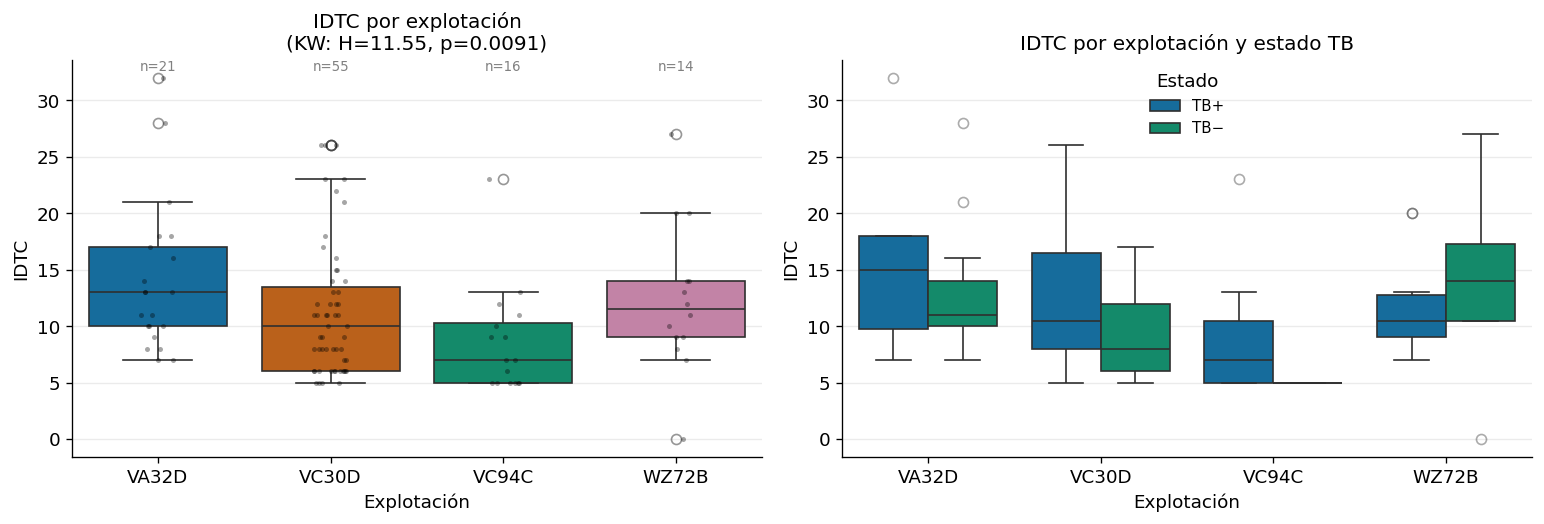

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Boxplot IDTC por explotación
ax = axes[0]
sns.boxplot(data=df, x=tb.GROUP_COL, y="IDTC", order=EXPLOTS,
            palette=EXPL_COLORS, ax=ax, flierprops=dict(alpha=0.5))
sns.stripplot(data=df, x=tb.GROUP_COL, y="IDTC", order=EXPLOTS,
              color="black", alpha=0.35, size=3, ax=ax, jitter=True)
ax.set_title(f"IDTC por explotación\n(KW: H={H_idtc:.2f}, p={p_idtc:.4f})")
ax.set_xlabel("Explotación"); ax.set_ylabel("IDTC")
for i, granja in enumerate(EXPLOTS):
    n = (df[tb.GROUP_COL] == granja).sum()
    ax.text(i, df["IDTC"].max() * 1.02, f"n={n}", ha="center", fontsize=8, color="grey")

# IDTC separado por estado TB
ax2 = axes[1]
df_plot = df.copy()
df_plot["Estado"] = df_plot["Lesiones_TB"].map({0: "TB−", 1: "TB+"})
sns.boxplot(data=df_plot, x=tb.GROUP_COL, y="IDTC", hue="Estado",
            order=EXPLOTS, palette={"TB−": PALETTE[2], "TB+": PALETTE[0]},
            ax=ax2, flierprops=dict(alpha=0.4))
ax2.set_title("IDTC por explotación y estado TB")
ax2.set_xlabel("Explotación"); ax2.set_ylabel("IDTC")
ax2.legend(title="Estado", fontsize=9)

plt.tight_layout()
plt.savefig("figures/fig_05_idtc_por_explotacion.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Biomarcadores (VitD, Calcio, serología) por explotación

Se comparan los biomarcadores entre explotaciones para entender si las diferencias
en prevalencia de lesiones podrían estar mediadas por diferencias en los perfiles
biológicos de los animales de cada granja.

> Esto es descriptivo-exploratorio: **no implica causalidad** ni se ajustan confusores.

In [16]:
BIOM_CONT = ["VITAMINA_D", "CALCIO", "PIROPLASMA_Q", "EDAD"]
BIOM_BIN  = ["PIROPLASMA", "THEILERIA", "ANAPLASMA"]

# Kruskal-Wallis para cada biomarcador continuo
print("Kruskal-Wallis: biomarcadores continuos ~ Explotación\n")
kw_results = []
for var in BIOM_CONT:
    groups_v = [df[df[tb.GROUP_COL] == g][var].dropna().values for g in EXPLOTS]
    if all(len(g) >= 2 for g in groups_v):
        H_v, p_v = kruskal(*groups_v)
        sig = "*" if p_v < 0.05 else ""
        kw_results.append({"Variable": tb.PRETTY.get(var, var), "H": round(H_v, 3), "p": round(p_v, 4), "Sig.": sig})
        print(f"  {tb.PRETTY.get(var, var):35s}: H={H_v:.3f}, p={p_v:.4f} {sig}")

# Chi-cuadrado para biomarcadores binarios
print("\nChi-cuadrado: biomarcadores binarios ~ Explotación\n")
for var in BIOM_BIN:
    ct = pd.crosstab(df[tb.GROUP_COL], df[var].dropna())
    if ct.shape == (len(EXPLOTS), 2):
        chi2_v, p_v, _, _ = chi2_contingency(ct)
        sig = "*" if p_v < 0.05 else ""
        print(f"  {tb.PRETTY.get(var, var):35s}: χ²={chi2_v:.3f}, p={p_v:.4f} {sig}")

Kruskal-Wallis: biomarcadores continuos ~ Explotación

  Vitamina D                         : H=21.399, p=0.0001 *
  Calcio                             : H=10.635, p=0.0139 *
  Carga piroplasma (q)               : H=29.546, p=0.0000 *
  Edad (años)                        : H=10.864, p=0.0125 *

Chi-cuadrado: biomarcadores binarios ~ Explotación

  Piroplasma (+)                     : χ²=30.543, p=0.0000 *
  Theileria spp. (+)                 : χ²=26.534, p=0.0000 *
  Anaplasma spp. (+)                 : χ²=31.091, p=0.0000 *


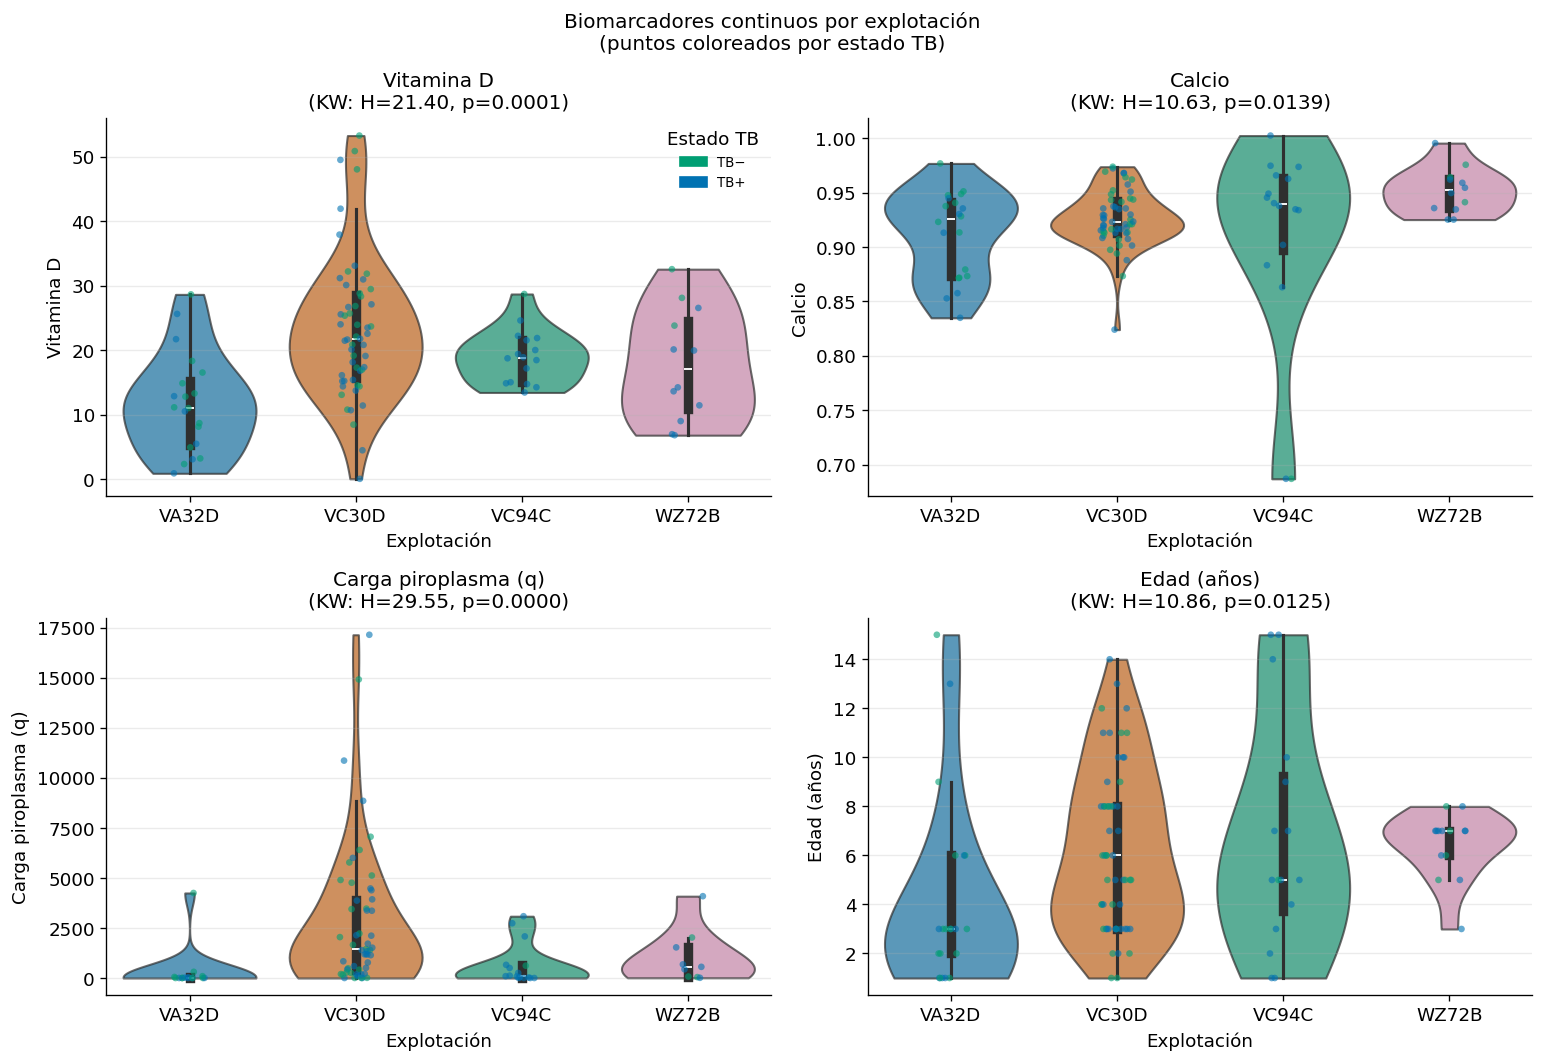

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, var in zip(axes.flat, BIOM_CONT):
    g_data = [df[df[tb.GROUP_COL] == g][var].dropna().values for g in EXPLOTS]
    H_v, p_v = kruskal(*[g for g in g_data if len(g) >= 2])
    
    sns.violinplot(data=df, x=tb.GROUP_COL, y=var, order=EXPLOTS,
                   palette=EXPL_COLORS, inner="box", ax=ax, alpha=0.7, cut=0)
    sns.stripplot(data=df, x=tb.GROUP_COL, y=var, hue="Lesiones_TB", order=EXPLOTS,
                  palette={0: PALETTE[2], 1: PALETTE[0]}, jitter=True,
                  alpha=0.6, size=4, ax=ax, legend=ax == axes.flat[0])
    ax.set_title(f"{tb.PRETTY.get(var, var)}\n(KW: H={H_v:.2f}, p={p_v:.4f})")
    ax.set_xlabel("Explotación"); ax.set_ylabel(tb.PRETTY.get(var, var))
    
    # Leyenda solo en primer panel
    if ax == axes.flat[0]:
        handles = [
            mpatches.Patch(color=PALETTE[2], label="TB−"),
            mpatches.Patch(color=PALETTE[0], label="TB+")
        ]
        ax.legend(handles=handles, title="Estado TB", fontsize=8, loc="upper right")

plt.suptitle("Biomarcadores continuos por explotación\n(puntos coloreados por estado TB)",
             fontsize=12)
plt.tight_layout()
plt.savefig("figures/fig_05_biomarkers_por_explotacion.png", dpi=150, bbox_inches="tight")
plt.show()

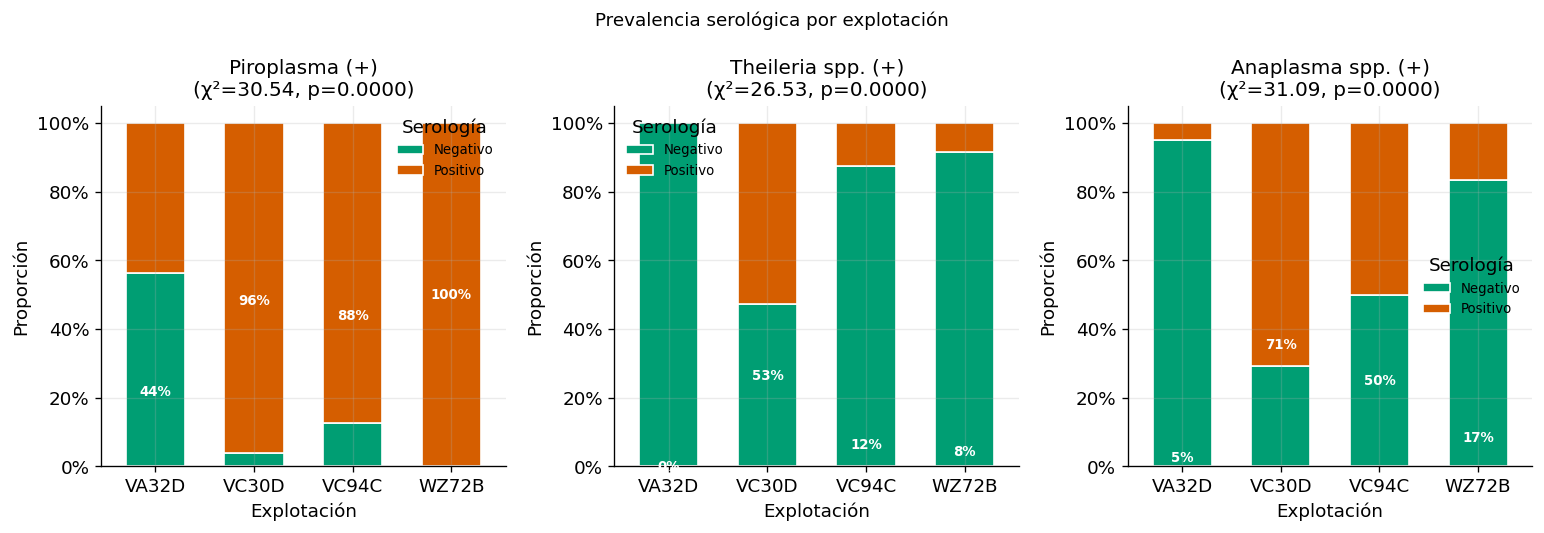

In [18]:
# Serología por explotación
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, var in zip(axes, BIOM_BIN):
    ct = pd.crosstab(df[tb.GROUP_COL], df[var])
    ct.columns = ["Neg.", "Pos."]
    prop = ct.div(ct.sum(axis=1), axis=0)
    prop.plot(kind="bar", stacked=True, ax=ax,
              color=[PALETTE[2], PALETTE[1]], edgecolor="white", width=0.6)
    chi2_v, p_v, _, _ = chi2_contingency(ct)
    ax.set_title(f"{tb.PRETTY.get(var, var)}\n(χ²={chi2_v:.2f}, p={p_v:.4f})")
    ax.set_xlabel("Explotación"); ax.set_ylabel("Proporción")
    ax.set_xticklabels(EXPLOTS, rotation=0)
    ax.legend(["Negativo", "Positivo"], fontsize=8, title="Serología")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    for i, granja in enumerate(EXPLOTS):
        p_pos = prop.loc[granja, "Pos."] if granja in prop.index else 0
        ax.text(i, p_pos / 2, f"{p_pos:.0%}", ha="center", va="center",
                fontsize=8, color="white", fontweight="bold")

plt.suptitle("Prevalencia serológica por explotación", fontsize=11)
plt.tight_layout()
plt.savefig("figures/fig_05_serologia_por_explotacion.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Relación Score lesional — biomarcadores, estratificado por explotación

Correlaciones de Spearman entre Score lesional y cada biomarcador continuo,
calculadas dentro de cada explotación y en el conjunto global.

In [19]:
corr_rows = []
for granja in ["GLOBAL"] + EXPLOTS:
    sub = df if granja == "GLOBAL" else df[df[tb.GROUP_COL] == granja]
    for var in BIOM_CONT:
        valid = sub[[var, "Score_lesional"]].dropna()
        if len(valid) >= 5:
            rho, p_rho = spearmanr(valid[var], valid["Score_lesional"])
            sig = "*" if p_rho < 0.05 else ""
            corr_rows.append({
                "Explotación": granja, "Variable": tb.PRETTY.get(var, var),
                "ρ (Spearman)": round(rho, 3), "p": round(p_rho, 4),
                "n": len(valid), "Sig.": sig
            })

corr_df = pd.DataFrame(corr_rows)
print("Correlaciones Spearman: biomarcador ~ Score lesional, por explotación:")
display(corr_df.pivot_table(
    index="Variable", columns="Explotación", values="ρ (Spearman)"
).round(3))

Correlaciones Spearman: biomarcador ~ Score lesional, por explotación:


Explotación,GLOBAL,VA32D,VC30D,VC94C,WZ72B
Variable,,,,,
Calcio,0.011,-0.336,0.005,0.175,-0.363
Carga piroplasma (q),-0.138,-0.154,-0.129,-0.396,0.183
Edad (años),0.128,-0.100,0.160,-0.075,0.021
Vitamina D,-0.079,-0.082,-0.167,-0.551,-0.697


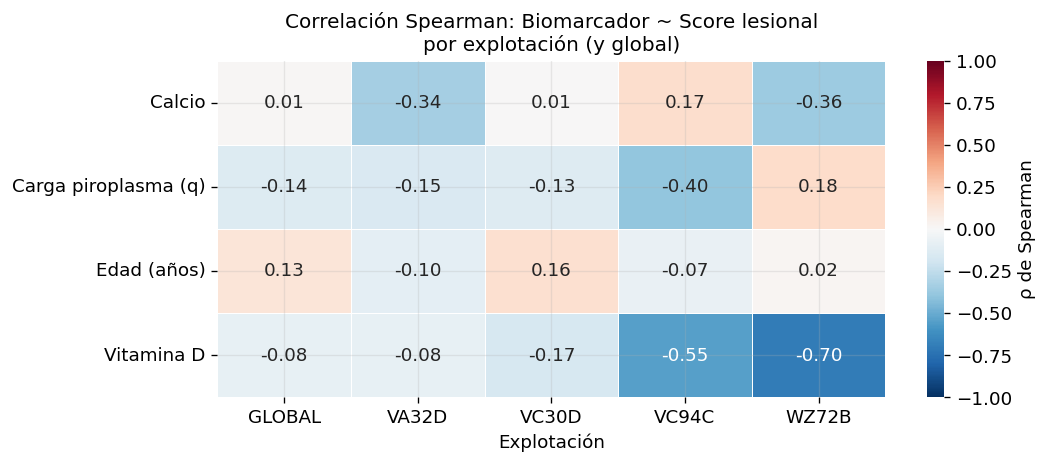

In [20]:
heat_corr = corr_df.pivot_table(
    index="Variable", columns="Explotación", values="ρ (Spearman)"
).round(3)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(heat_corr, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={"label": "ρ de Spearman"})
ax.set_title("Correlación Spearman: Biomarcador ~ Score lesional\npor explotación (y global)")
ax.set_xlabel("Explotación"); ax.set_ylabel("")
plt.tight_layout()
plt.savefig("figures/fig_05_spearman_score_biomarkers.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Tabla resumen consolidada

In [21]:
print("=" * 70)
print("TABLA RESUMEN COMPLETA POR EXPLOTACIÓN")
print("=" * 70)

summary_rows = []
for granja in EXPLOTS:
    g     = df[df[tb.GROUP_COL] == granja]
    g_pos = g[g["Lesiones_TB"] == 1]
    n     = len(g)
    n_pos = int(g["Lesiones_TB"].sum())
    prev  = n_pos / n
    lo, hi = proportion_confint(n_pos, n, alpha=0.05, method="wilson")

    # Score lesional
    sl_med  = g["Score_lesional"].median()
    sl_iqr  = g["Score_lesional"].quantile([0.25, 0.75]).values

    # Patrón (solo TB+)
    n_gen = int((g_pos["Patron_lesiones"] == 1).sum()) if len(g_pos) > 0 else 0
    p_gen = f"{n_gen}/{n_pos} ({n_gen/n_pos:.0%})" if n_pos > 0 else "—"

    # IDTC
    idtc_med = g["IDTC"].median()
    idtc_iqr = g["IDTC"].quantile([0.25, 0.75]).values

    # VitD
    vd_med = g["VITAMINA_D"].median()
    vd_iqr = g["VITAMINA_D"].quantile([0.25, 0.75]).values

    summary_rows.append({
        "Explotación": granja,
        "n": n,
        "TB+ (n)": n_pos,
        "Prevalencia [IC95%]": f"{prev:.1%} [{lo:.1%}–{hi:.1%}]",
        "Score med [IQR]": f"{sl_med:.1f} [{sl_iqr[0]:.1f}–{sl_iqr[1]:.1f}]",
        "Patrón gen. (entre TB+)": p_gen,
        "IDTC med [IQR]": f"{idtc_med:.1f} [{idtc_iqr[0]:.1f}–{idtc_iqr[1]:.1f}]",
        "VitD med [IQR]": f"{vd_med:.1f} [{vd_iqr[0]:.1f}–{vd_iqr[1]:.1f}]",
    })

# Añadir fila global
g = df
g_pos = df[df["Lesiones_TB"] == 1]
n = len(g); n_pos = int(g["Lesiones_TB"].sum()); prev = n_pos / n
lo, hi = proportion_confint(n_pos, n, alpha=0.05, method="wilson")
sl_med = g["Score_lesional"].median(); sl_iqr = g["Score_lesional"].quantile([0.25, 0.75]).values
n_gen  = int((g_pos["Patron_lesiones"] == 1).sum())
p_gen  = f"{n_gen}/{n_pos} ({n_gen/n_pos:.0%})"
idtc_med = g["IDTC"].median(); idtc_iqr = g["IDTC"].quantile([0.25, 0.75]).values
vd_med   = g["VITAMINA_D"].median(); vd_iqr = g["VITAMINA_D"].quantile([0.25, 0.75]).values
summary_rows.append({
    "Explotación": "GLOBAL",
    "n": n, "TB+ (n)": n_pos,
    "Prevalencia [IC95%]": f"{prev:.1%} [{lo:.1%}–{hi:.1%}]",
    "Score med [IQR]": f"{sl_med:.1f} [{sl_iqr[0]:.1f}–{sl_iqr[1]:.1f}]",
    "Patrón gen. (entre TB+)": p_gen,
    "IDTC med [IQR]": f"{idtc_med:.1f} [{idtc_iqr[0]:.1f}–{idtc_iqr[1]:.1f}]",
    "VitD med [IQR]": f"{vd_med:.1f} [{vd_iqr[0]:.1f}–{vd_iqr[1]:.1f}]",
})

summ_df = pd.DataFrame(summary_rows)
display(summ_df)

print("\n--- Tests estadísticos globales ---")
print(f"Lesiones_TB ~ Expl:    χ²({dof}) = {chi2:.3f}, p = {p_chi2:.4f}")
print(f"Score lesional ~ Expl: H = {H:.3f}, p = {p_kw:.4f}")
print(f"Patrón ~ Expl (TB+):   χ²({dof_pat}) = {chi2_pat:.3f}, p = {p_chi2_pat:.4f}")
print(f"IDTC ~ Expl:           H = {H_idtc:.3f}, p = {p_idtc:.4f}")

TABLA RESUMEN COMPLETA POR EXPLOTACIÓN


,Explotación,n,TB+ (n),Prevalencia [IC95%],Score med [IQR],Patrón gen. (entre TB+),IDTC med [IQR],VitD med [IQR]
0,VA32D,21,8,38.1% [20.8%–59.1%],0.0 [0.0–2.0],3/8 (38%),13.0 [10.0–17.0],11.1 [5.4–15.3]
1,VC30D,55,32,58.2% [45.0%–70.3%],1.0 [0.0–2.0],8/32 (25%),10.0 [6.0–13.5],21.8 [15.8–28.6]
2,VC94C,16,15,93.8% [71.7%–98.9%],5.0 [5.0–5.0],13/15 (87%),7.0 [5.0–10.2],18.8 [15.0–21.6]
3,WZ72B,14,10,71.4% [45.4%–88.3%],1.0 [0.2–1.0],0/10 (0%),11.5 [9.0–14.0],17.1 [10.9–24.5]
4,GLOBAL,106,65,61.3% [51.8%–70.0%],1.0 [0.0–2.0],24/65 (37%),10.0 [7.0–14.0],18.9 [13.5–25.5]



--- Tests estadísticos globales ---
Lesiones_TB ~ Expl:    χ²(3) = 12.702, p = 0.0053
Score lesional ~ Expl: H = 29.988, p = 0.0000
Patrón ~ Expl (TB+):   χ²(3) = 23.745, p = 0.0000
IDTC ~ Expl:           H = 11.548, p = 0.0091


## 11. Análisis no supervisado (clustering) — ¿se agrupan los animales por explotación?

Pregunta: ¿la explotación emerge como estructura natural en el espacio de los
biomarcadores, **sin usar la etiqueta de granja** como información de entrenamiento?

Si los animales se agrupan espontáneamente por explotación es evidencia de que la
granja introduce diferencias sistemáticas en el perfil biológico (VitD, calcio, parásitos,
edad) que van más allá del azar.

**Análisis realizados:**

| Método | Naturaleza | Pregunta que responde |
|---|---|---|
| PCA | Lineal | ¿Qué features explican más varianza? ¿Se separan visualmente las granjas? |
| Clustering jerárquico + clustermap | Aglomerativo | ¿Qué animales son más similares entre sí? |
| k-means | Partitivo | ¿Cuántos grupos "naturales" hay? ¿Coinciden con las granjas? |
| t-SNE / UMAP | No lineal | ¿Hay separación no lineal entre granjas? |
| PERMANOVA | Test permutacional | ¿Son los centroides multivariantes de las granjas significativamente distintos? |
| Silhouette coefficient | Métrica | ¿Qué tan compactas y separadas están las granjas en el espacio de biomarcadores? |

> **Nota:** las features de clustering son exclusivamente biomarcadores individuales
> (`VITAMINA_D`, `CALCIO`, `PIROPLASMA_Q_log`, `EDAD`, `PIROPLASMA`, `THEILERIA`,
> `ANAPLASMA`). No se incluyen ni `Lesiones_TB` ni `Score_lesional` para evitar
> circularidad.

In [22]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    adjusted_rand_score, normalized_mutual_info_score, v_measure_score,
)
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform

# Features para clustering (solo biomarcadores, sin outcomes de lesiones ni raza)
FEAT_CLUST  = ["VITAMINA_D", "CALCIO", "PIROPLASMA_Q_log", "EDAD",
               "PIROPLASMA", "THEILERIA", "ANAPLASMA"]
FEAT_LABELS = [tb.PRETTY.get(f, f) for f in FEAT_CLUST]

# --- Eliminacion de filas con cualquier NaN (datos originales, sin imputacion) ---
n_orig = len(df)
df_clust = df[FEAT_CLUST + [tb.GROUP_COL, "Lesiones_TB"]].dropna(subset=FEAT_CLUST).copy()
n_drop = n_orig - len(df_clust)

print(f"Animales totales:              {n_orig}")
print(f"Eliminados por algun NaN:      {n_drop}")
print(f"Animales para clustering:      {len(df_clust)}")
print()
na_by_feat = df[FEAT_CLUST].isna().sum()
na_by_feat = na_by_feat[na_by_feat > 0]
if len(na_by_feat):
    print("NaN por feature (filas eliminadas):")
    for f, n in na_by_feat.items():
        print(f"  {tb.PRETTY.get(f, f)}: {n} animales")
else:
    print("Sin NaN en las features de clustering.")
print()

scaler = StandardScaler()
X_raw = df_clust[FEAT_CLUST].values      # valores originales (sin imputar)
X_sc  = scaler.fit_transform(X_raw)     # solo escalado

grp     = df_clust[tb.GROUP_COL].values
les     = df_clust["Lesiones_TB"].fillna(0).astype(int).values
grp_num = np.array([EXPLOTS.index(g) for g in grp])

print(f"Matriz de clustering: {X_sc.shape[0]} animales x {X_sc.shape[1]} features")
print("Distribucion por explotacion:")
for g in EXPLOTS:
    print(f"  {g}: n={np.sum(grp == g)}")


Animales totales:              106
Eliminados por algun NaN:      12
Animales para clustering:      94

NaN por feature (filas eliminadas):
  Vitamina D: 3 animales
  Calcio: 3 animales
  log(1+Carga piroplasma): 12 animales
  Piroplasma (+): 11 animales
  Theileria spp. (+): 3 animales
  Anaplasma spp. (+): 3 animales

Matriz de clustering: 94 animales x 7 features
Distribucion por explotacion:
  VA32D: n=15
  VC30D: n=54
  VC94C: n=16
  WZ72B: n=9


## 12. Análisis de Componentes Principales (PCA)

PCA proyecta los 7 biomarcadores en un espacio de menor dimensión maximizando la
varianza explicada. Si las explotaciones aparecen separadas en los primeros componentes,
es señal de que el perfil biológico de cada granja es sistemáticamente distinto.

- **Scree plot**: varianza explicada acumulada por cada PC.
- **Scatter PC1 × PC2**: puntos coloreados por explotación y por estado TB.
- **Biplot**: superpone los vectores de carga para identificar qué biomarcadores
  orientan cada eje.
- **Heatmap de loadings**: para los 4 primeros PCs.


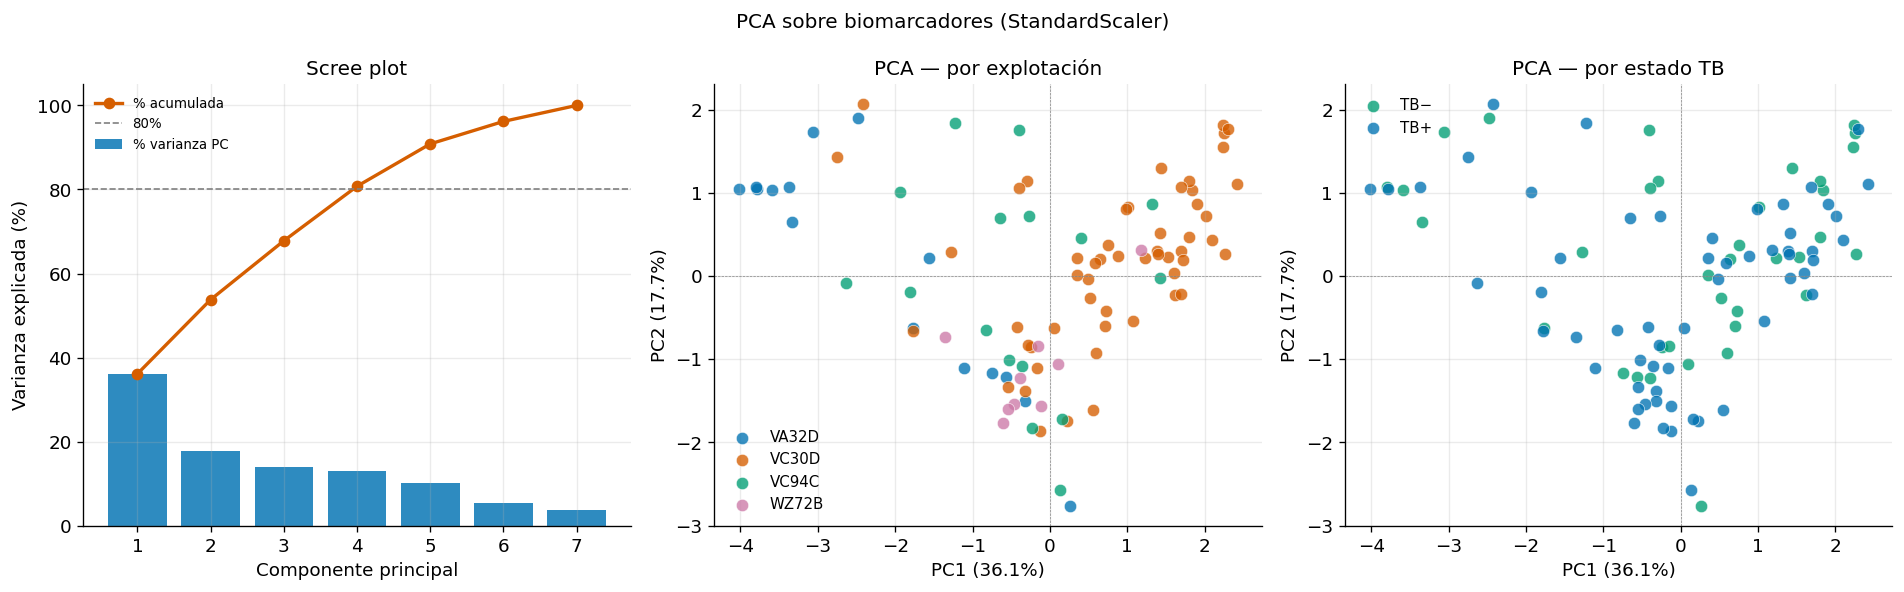

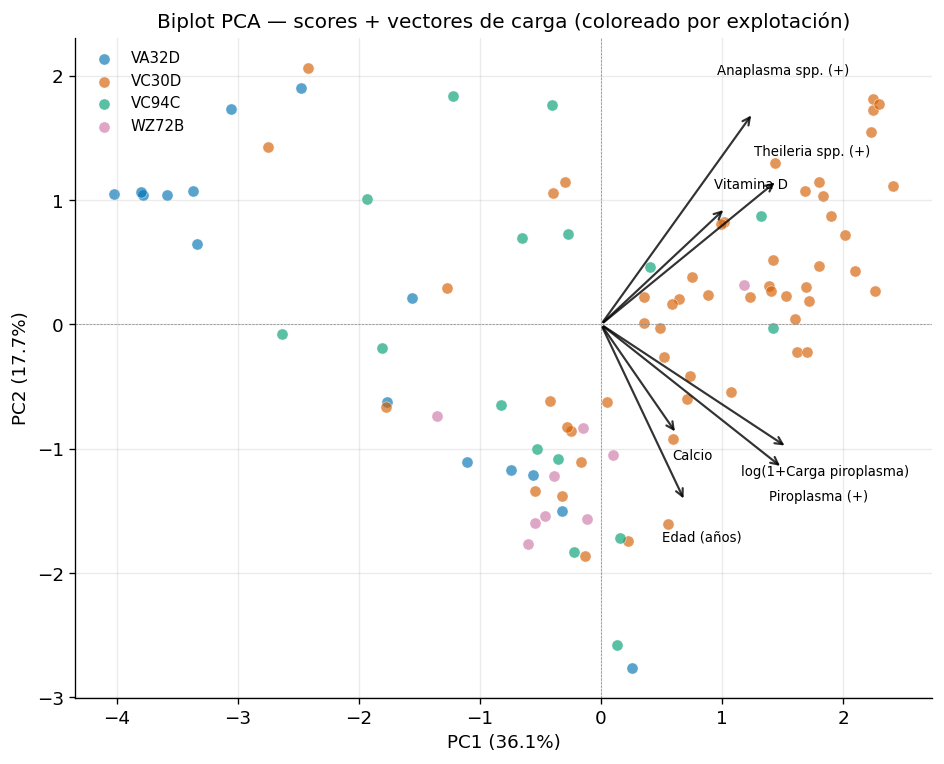

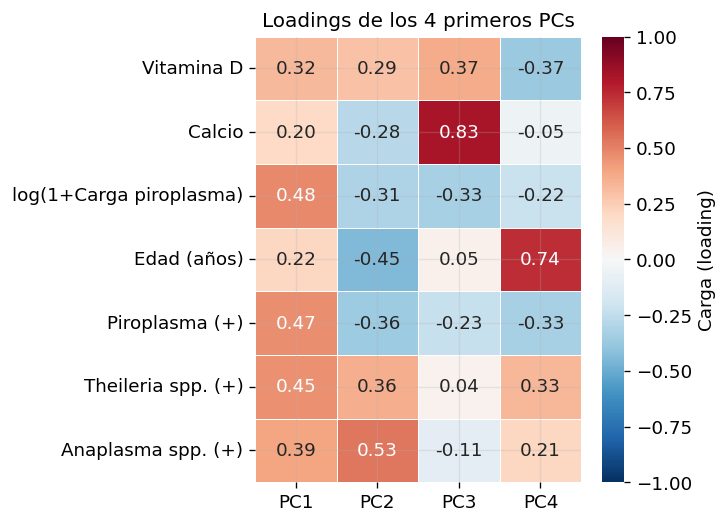

Varianza explicada por PC:
  PC1: 36.1% (acum: 36.1%)
  PC2: 17.7% (acum: 53.8%)
  PC3: 14.0% (acum: 67.8%)
  PC4: 13.0% (acum: 80.8%)
  PC5: 10.1% (acum: 90.8%)
  PC6: 5.3% (acum: 96.2%)
  PC7: 3.8% (acum: 100.0%)


In [23]:
pca   = PCA(n_components=len(FEAT_CLUST), random_state=tb.SEED)
Z_pca = pca.fit_transform(X_sc)
var   = pca.explained_variance_ratio_
load  = pca.components_.T           # shape (n_features, n_components)

# ── Scree + scatter ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
cumvar = np.cumsum(var) * 100
ax.bar(range(1, len(var)+1), var*100, color=PALETTE[0], alpha=0.82, label="% varianza PC")
ax.plot(range(1, len(cumvar)+1), cumvar, "o-", color=PALETTE[1], lw=2, ms=6,
        label="% acumulada")
ax.axhline(80, ls="--", color="grey", lw=1, label="80%")
ax.set_xticks(range(1, len(var)+1))
ax.set_xlabel("Componente principal"); ax.set_ylabel("Varianza explicada (%)")
ax.set_title("Scree plot"); ax.legend(fontsize=8)

for col_ax, color_by, title in [
    (1, "expl", "PCA — por explotación"),
    (2, "tb",   "PCA — por estado TB"),
]:
    ax = axes[col_ax]
    if color_by == "expl":
        for g in EXPLOTS:
            m = grp == g
            ax.scatter(Z_pca[m,0], Z_pca[m,1], color=EXPL_COLORS[g], label=g,
                       alpha=0.78, s=55, edgecolors="white", lw=0.4)
        ax.legend(fontsize=9)
    else:
        for tb_val, lbl, col in [(0, "TB−", PALETTE[2]), (1, "TB+", PALETTE[0])]:
            m = les == tb_val
            ax.scatter(Z_pca[m,0], Z_pca[m,1], color=col, label=lbl,
                       alpha=0.78, s=55, edgecolors="white", lw=0.4)
        ax.legend(fontsize=9)
    ax.axhline(0, color="grey", lw=0.4, ls="--")
    ax.axvline(0, color="grey", lw=0.4, ls="--")
    ax.set_xlabel(f"PC1 ({var[0]:.1%})")
    ax.set_ylabel(f"PC2 ({var[1]:.1%})")
    ax.set_title(title)

plt.suptitle("PCA sobre biomarcadores (StandardScaler)", fontsize=12)
plt.tight_layout()
plt.savefig("figures/fig_05_pca_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Biplot (PC1 × PC2) ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6.5))
for g in EXPLOTS:
    m = grp == g
    ax.scatter(Z_pca[m,0], Z_pca[m,1], color=EXPL_COLORS[g], label=g,
               alpha=0.65, s=45, edgecolors="white", lw=0.4)
sc = 3.2
for i, feat in enumerate(FEAT_CLUST):
    ax.annotate("", xy=(load[i,0]*sc, load[i,1]*sc), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="black", lw=1.3, alpha=0.8))
    ax.text(load[i,0]*sc*1.20, load[i,1]*sc*1.20,
            FEAT_LABELS[i], fontsize=8, ha="center", va="center")
ax.axhline(0, color="grey", lw=0.4, ls="--")
ax.axvline(0, color="grey", lw=0.4, ls="--")
ax.set_xlabel(f"PC1 ({var[0]:.1%})")
ax.set_ylabel(f"PC2 ({var[1]:.1%})")
ax.set_title("Biplot PCA — scores + vectores de carga (coloreado por explotación)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("figures/fig_05_pca_biplot.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Heatmap de loadings ───────────────────────────────────────────────────────
n_pc_show = min(4, len(FEAT_CLUST))
load_df = pd.DataFrame(
    load[:, :n_pc_show],
    index=FEAT_LABELS,
    columns=[f"PC{i+1}" for i in range(n_pc_show)],
)
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(load_df, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={"label": "Carga (loading)"})
ax.set_title("Loadings de los 4 primeros PCs")
plt.tight_layout()
plt.savefig("figures/fig_05_pca_loadings.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Resumen numérico ──────────────────────────────────────────────────────────
print(f"Varianza explicada por PC:")
for i, v in enumerate(var):
    print(f"  PC{i+1}: {v:.1%} (acum: {np.cumsum(var)[i]:.1%})")


## 13. Clustering jerárquico (Ward) + clustermap

El **dendrograma** muestra la similitud entre animales sin imponer un número de
clusters. Se usa la tira de color inferior para visualizar a qué explotación pertenece
cada hoja en el orden del dendrograma.

El **clustermap** combina el dendrograma con un heatmap de las variables: permite ver
si los bloques de color del heatmap coinciden con la anotación de explotación.


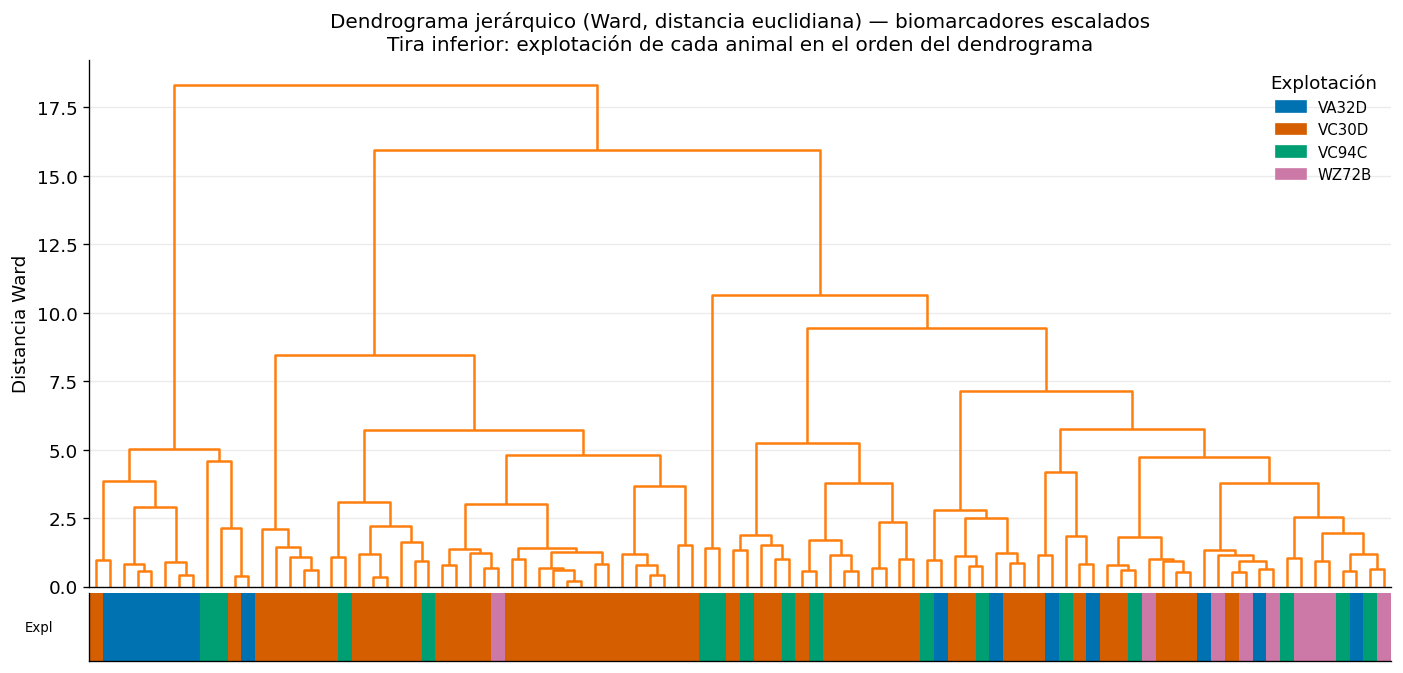

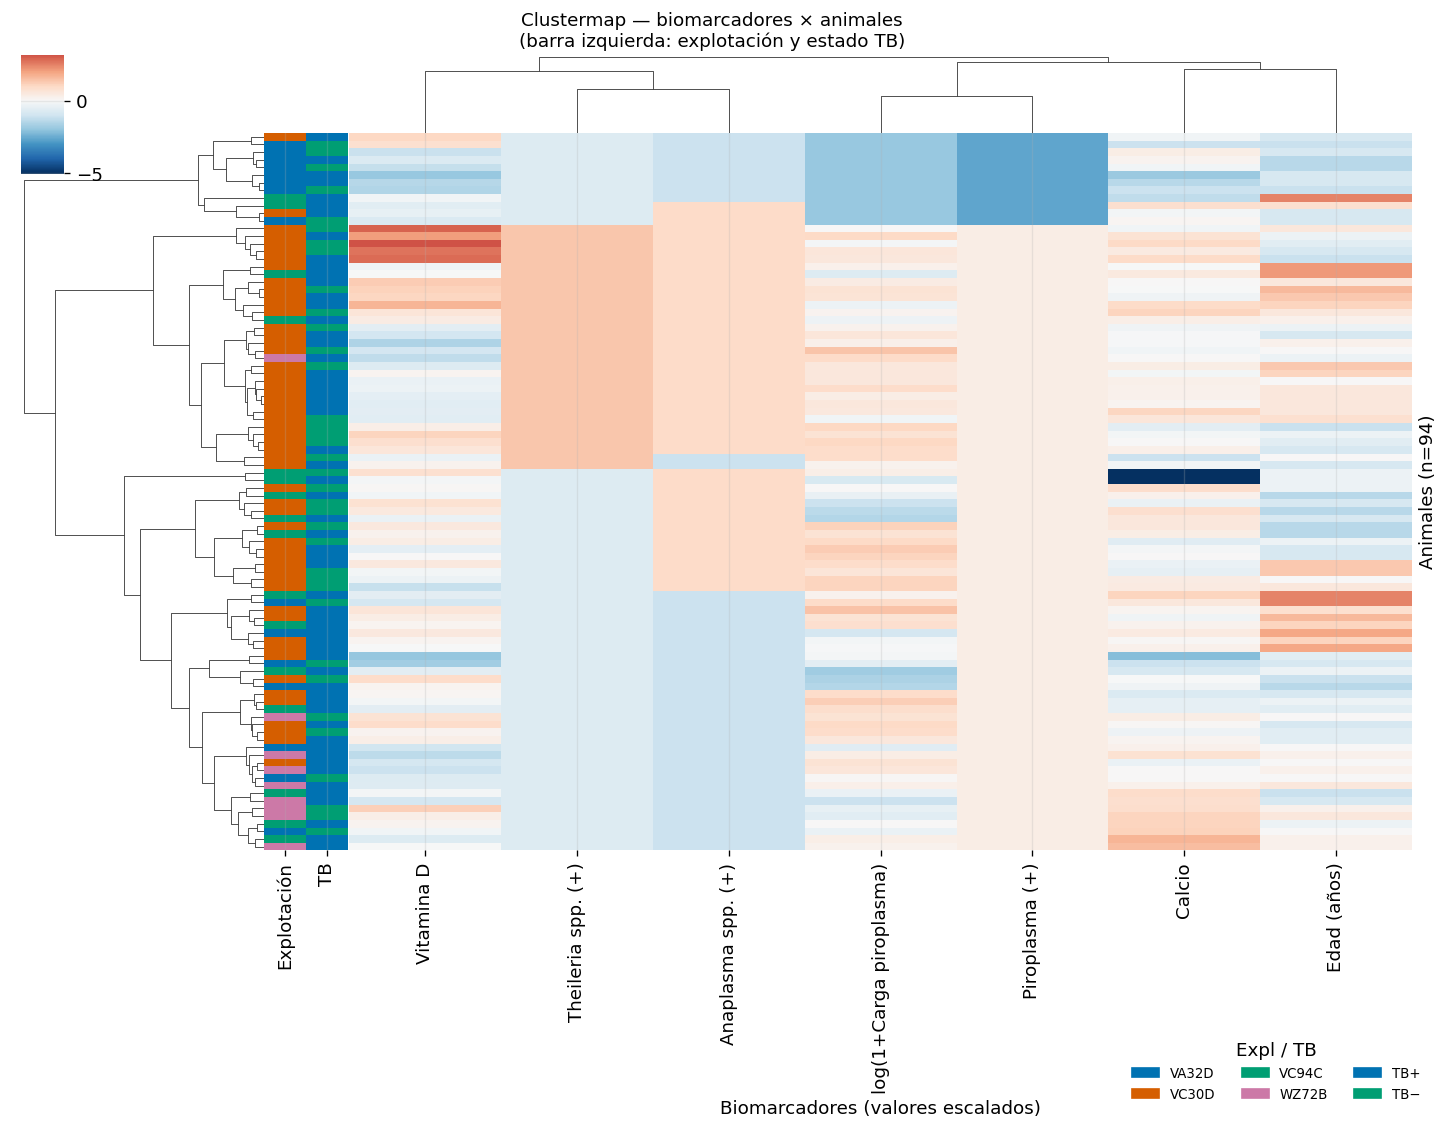

In [24]:
linked = linkage(X_sc, method="ward")

# ── Dendrograma con tira de color por explotación ─────────────────────────────
fig, (ax_d, ax_c) = plt.subplots(
    2, 1, figsize=(14, 6.5),
    gridspec_kw={"height_ratios": [5, 0.65]},
    sharex=True,
)
fig.subplots_adjust(hspace=0.02)

dend = dendrogram(linked, ax=ax_d, no_labels=True,
                  color_threshold=np.inf, above_threshold_color="#3a86ff")
leaf_order = dend["leaves"]
n_lv = len(leaf_order)

# Tira de color: una barra por hoja en el orden del dendrograma
x_pos = np.arange(n_lv) * 10 + 5
for xi, idx in zip(x_pos, leaf_order):
    ax_c.bar(xi, 1, width=10, color=EXPL_COLORS[grp[idx]], linewidth=0, align="center")

ax_c.set_ylim(0, 1); ax_c.set_yticks([]); ax_c.set_xticks([])
ax_c.set_ylabel("Expl", fontsize=8, rotation=0, labelpad=30, va="center")

patches_leg = [mpatches.Patch(color=EXPL_COLORS[g], label=g) for g in EXPLOTS]
ax_d.legend(handles=patches_leg, fontsize=9, loc="upper right", title="Explotación")
ax_d.set_ylabel("Distancia Ward")
ax_d.set_title(
    "Dendrograma jerárquico (Ward, distancia euclidiana) — biomarcadores escalados\n"
    "Tira inferior: explotación de cada animal en el orden del dendrograma"
)
plt.savefig("figures/fig_05_dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Clustermap ────────────────────────────────────────────────────────────────
df_heat = pd.DataFrame(X_sc, columns=FEAT_LABELS)
row_ann = pd.DataFrame({
    "Explotación": [EXPL_COLORS[g] for g in grp],
    "TB":          [PALETTE[0] if l == 1 else PALETTE[2] for l in les],
})

g_cm = sns.clustermap(
    df_heat, method="ward", metric="euclidean",
    row_colors=row_ann,
    cmap="RdBu_r", center=0,
    xticklabels=True, yticklabels=False,
    figsize=(12, 9),
    dendrogram_ratio=(0.18, 0.10),
    cbar_pos=(0.02, 0.87, 0.03, 0.11),
)
g_cm.ax_heatmap.set_xlabel("Biomarcadores (valores escalados)")
g_cm.ax_heatmap.set_ylabel(f"Animales (n={len(df_heat)})")
g_cm.fig.suptitle(
    "Clustermap — biomarcadores × animales\n"
    "(barra izquierda: explotación y estado TB)",
    y=1.02, fontsize=11,
)
leg_p = [mpatches.Patch(color=EXPL_COLORS[g], label=g) for g in EXPLOTS]
leg_p += [mpatches.Patch(color=PALETTE[0], label="TB+"),
          mpatches.Patch(color=PALETTE[2], label="TB−")]
g_cm.fig.legend(handles=leg_p, loc="lower right", fontsize=8,
                ncol=3, title="Expl / TB",
                bbox_to_anchor=(1.0, 0.0))
g_cm.savefig("figures/fig_05_clustermap.png", dpi=150, bbox_inches="tight")
plt.show()


## 14. k-means: ¿cuántos grupos naturales existen?

Se ajustan modelos k-means para k = 2…7 y se evalúa:

- **Método del codo** (inertia): el punto donde añadir más clusters deja de reducir
  sustancialmente la inercia.
- **Silhouette score**: mide la calidad intrínseca del clustering (compactez vs separación).

Para k = 4 (igual que el número de explotaciones) se cuantifica el **alineamiento**
entre los clusters obtenidos y las granjas reales usando:

- **ARI** (Adjusted Rand Index): 0 = asignación aleatoria, 1 = perfecta.
- **NMI** (Normalized Mutual Information): idem.
- **V-measure**: media armónica de homogeneidad y completeness.


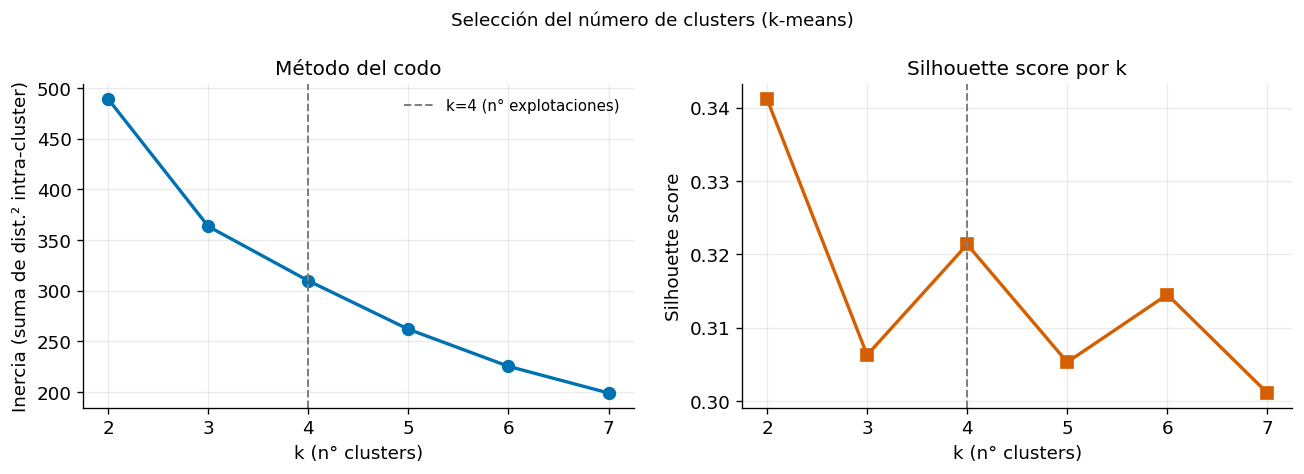

k-means con k=4 (= nº explotaciones):
  ARI  (Adjusted Rand Index)     = 0.104  [0=azar, 1=perfecto]
  NMI  (Normalized Mutual Info)  = 0.224  [0=independiente, 1=idéntico]
  V-measure                      = 0.224  [harmónica homog./completeness]
  Silhouette (clusters k-means)  = 0.332  [−1 a 1]

Tabla cluster × explotación (correspondencia):


Cluster k-means,0,1,2,3
Explotación,,,,
VA32D,7,8,0,0
VC30D,25,2,27,0
VC94C,10,2,2,2
WZ72B,8,0,1,0


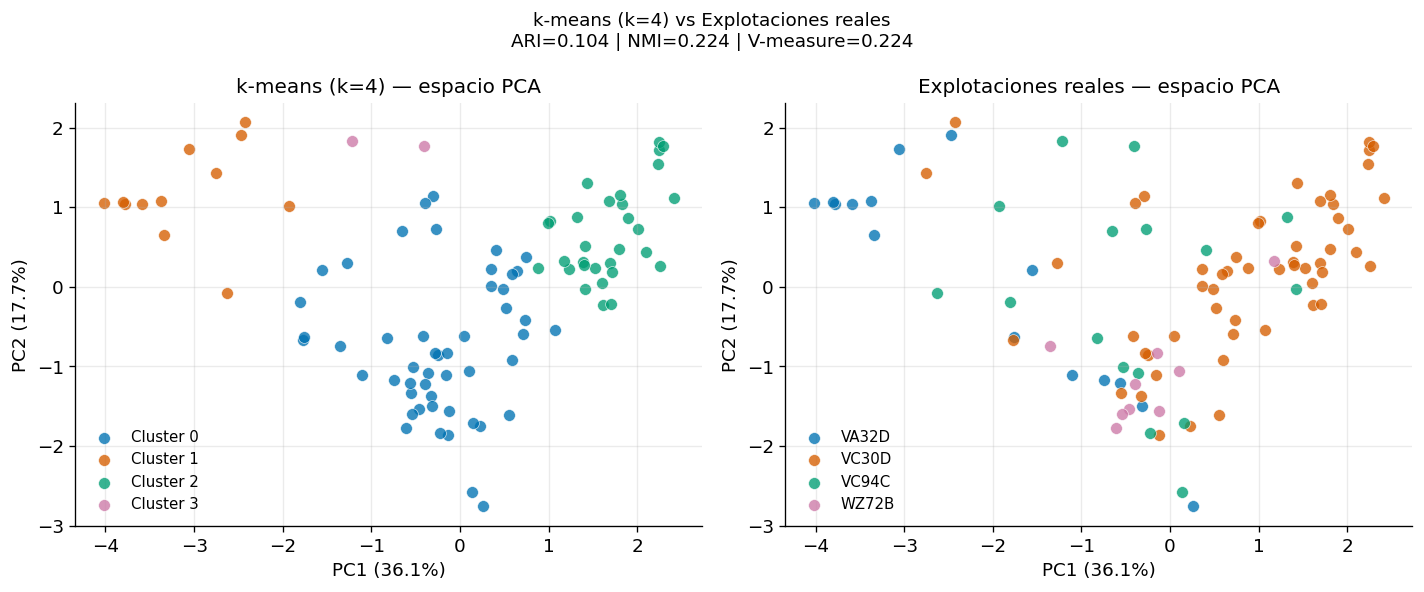

In [25]:
K_RANGE = range(2, 8)
inertias, sils_km = [], []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=tb.SEED, n_init=20)
    labs = km.fit_predict(X_sc)
    inertias.append(km.inertia_)
    sils_km.append(silhouette_score(X_sc, labs))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(K_RANGE), inertias, "o-", color=PALETTE[0], lw=2, ms=7)
axes[0].axvline(len(EXPLOTS), ls="--", color="grey", lw=1.2,
                label=f"k={len(EXPLOTS)} (n° explotaciones)")
axes[0].set_xlabel("k (n° clusters)"); axes[0].set_ylabel("Inercia (suma de dist.² intra-cluster)")
axes[0].set_title("Método del codo"); axes[0].legend(fontsize=9)

axes[1].plot(list(K_RANGE), sils_km, "s-", color=PALETTE[1], lw=2, ms=7)
axes[1].axvline(len(EXPLOTS), ls="--", color="grey", lw=1.2)
axes[1].set_xlabel("k (n° clusters)"); axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score por k")
plt.suptitle("Selección del número de clusters (k-means)", fontsize=11)
plt.tight_layout()
plt.savefig("figures/fig_05_kmeans_selection.png", dpi=150, bbox_inches="tight")
plt.show()

# ── k = nº explotaciones: alineamiento con granjas reales ────────────────────
km4      = KMeans(n_clusters=len(EXPLOTS), random_state=tb.SEED, n_init=50)
labs_km4 = km4.fit_predict(X_sc)

ari_km  = adjusted_rand_score(grp_num, labs_km4)
nmi_km  = normalized_mutual_info_score(grp_num, labs_km4)
vm_km   = v_measure_score(grp_num, labs_km4)
sil_km4 = silhouette_score(X_sc, labs_km4)

print(f"k-means con k={len(EXPLOTS)} (= nº explotaciones):")
print(f"  ARI  (Adjusted Rand Index)     = {ari_km:.3f}  [0=azar, 1=perfecto]")
print(f"  NMI  (Normalized Mutual Info)  = {nmi_km:.3f}  [0=independiente, 1=idéntico]")
print(f"  V-measure                      = {vm_km:.3f}  [harmónica homog./completeness]")
print(f"  Silhouette (clusters k-means)  = {sil_km4:.3f}  [−1 a 1]")

print("\nTabla cluster × explotación (correspondencia):")
ct_km = pd.crosstab(pd.Series(grp, name="Explotación"),
                    pd.Series(labs_km4, name="Cluster k-means"))
display(ct_km)

# ── Scatter: k-means vs explotaciones reales en espacio PCA ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
clust_pal = [PALETTE[i % len(PALETTE)] for i in range(len(EXPLOTS))]

for ci in range(len(EXPLOTS)):
    m = labs_km4 == ci
    axes[0].scatter(Z_pca[m,0], Z_pca[m,1], color=clust_pal[ci],
                    label=f"Cluster {ci}", alpha=0.78, s=50, edgecolors="white", lw=0.4)
axes[0].set_title(f"k-means (k={len(EXPLOTS)}) — espacio PCA")
axes[0].set_xlabel(f"PC1 ({var[0]:.1%})"); axes[0].set_ylabel(f"PC2 ({var[1]:.1%})")
axes[0].legend(fontsize=9)

for g in EXPLOTS:
    m = grp == g
    axes[1].scatter(Z_pca[m,0], Z_pca[m,1], color=EXPL_COLORS[g], label=g,
                    alpha=0.78, s=50, edgecolors="white", lw=0.4)
axes[1].set_title("Explotaciones reales — espacio PCA")
axes[1].set_xlabel(f"PC1 ({var[0]:.1%})"); axes[1].set_ylabel(f"PC2 ({var[1]:.1%})")
axes[1].legend(fontsize=9)

plt.suptitle(
    f"k-means (k={len(EXPLOTS)}) vs Explotaciones reales\n"
    f"ARI={ari_km:.3f} | NMI={nmi_km:.3f} | V-measure={vm_km:.3f}",
    fontsize=11,
)
plt.tight_layout()
plt.savefig("figures/fig_05_kmeans_vs_expl.png", dpi=150, bbox_inches="tight")
plt.show()


## 15. Embedding no lineal — t-SNE (y UMAP si disponible)

Los métodos no lineales pueden revelar separaciones que PCA no muestra. Se usan:

- **t-SNE** (t-distributed Stochastic Neighbor Embedding): preserva la estructura local.
  Con n=106 y `perplexity=20` (≈ n/5), el embedding es estable.
- **UMAP** (Uniform Manifold Approximation and Projection): más rápido y con mejor
  preservación de la estructura global que t-SNE. Se ejecuta si `umap-learn` está instalado.

> Los embeddings son estocásticos pero reproducibles con la semilla fijada.


t-SNE calculado.
UMAP calculado.


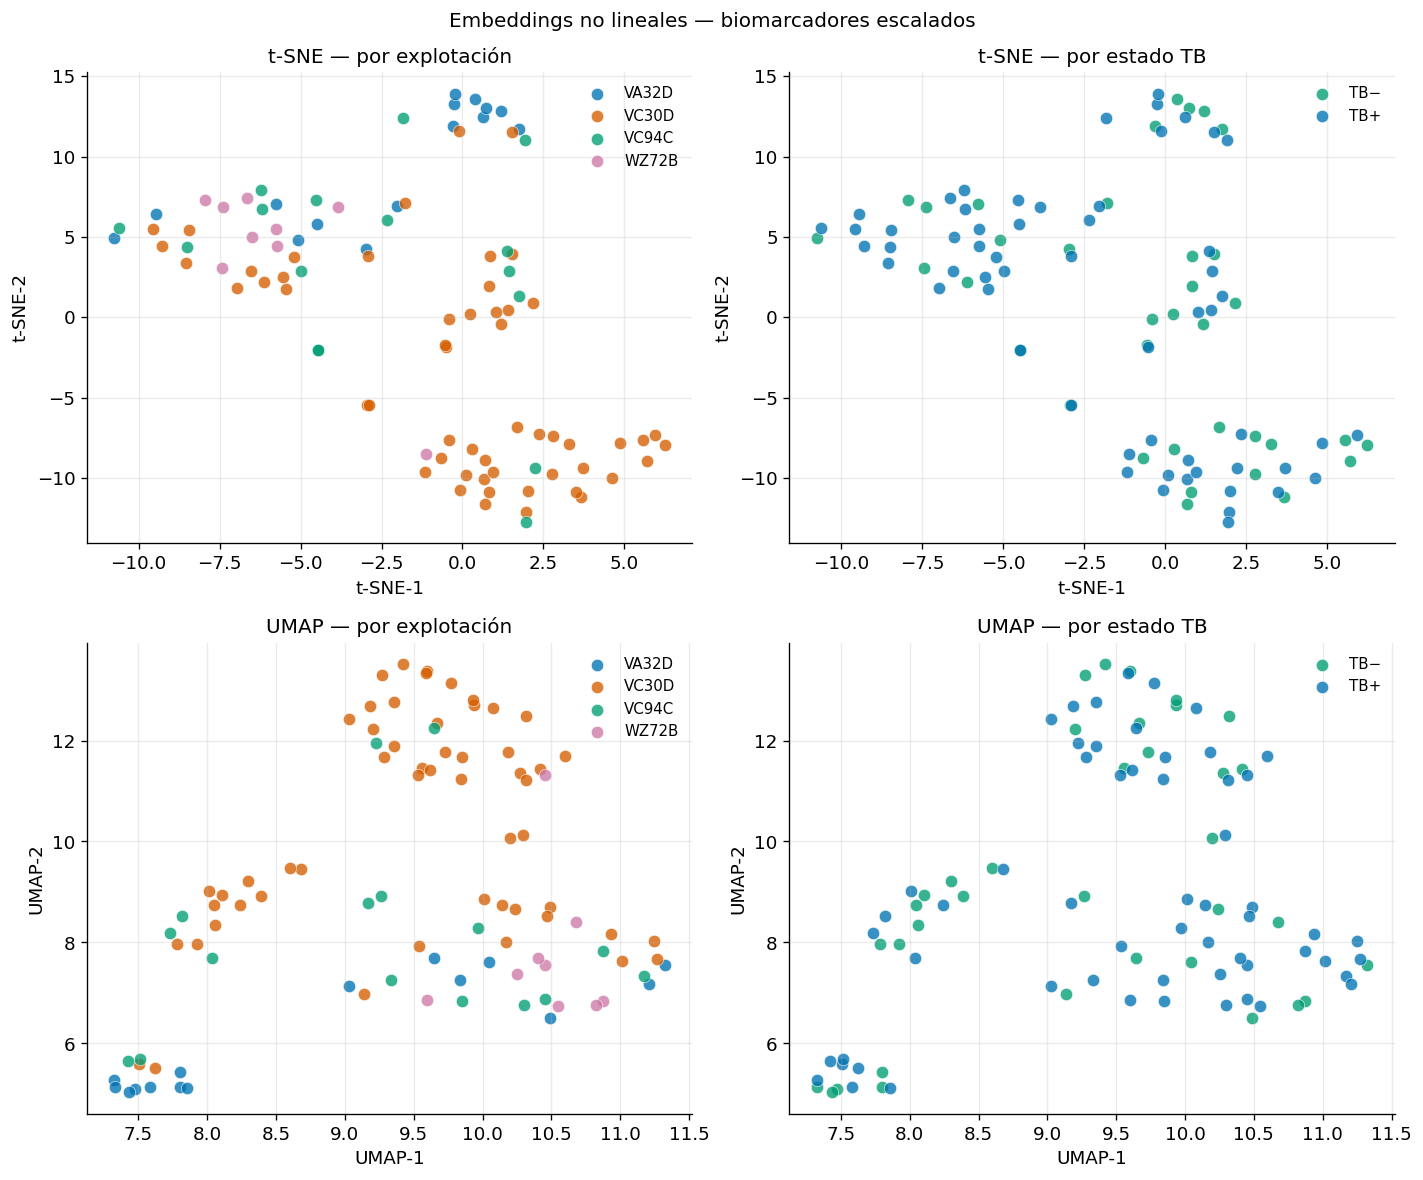

In [31]:
tsne   = TSNE(n_components=2, perplexity=20, random_state=tb.SEED, max_iter=1000)
Z_tsne = tsne.fit_transform(X_sc)
print("t-SNE calculado.")

try:
    import umap as umap_lib
    reducer = umap_lib.UMAP(n_components=2, random_state=tb.SEED,
                             n_neighbors=20, min_dist=0.1)
    Z_umap  = reducer.fit_transform(X_sc)
    HAS_UMAP = True
    print("UMAP calculado.")
except ImportError:
    HAS_UMAP = False
    print("umap-learn no instalado — se muestra solo t-SNE.")

embeds = [("t-SNE", Z_tsne)]
if HAS_UMAP:
    embeds.append(("UMAP", Z_umap))

fig, axes = plt.subplots(len(embeds), 2, figsize=(12, 5 * len(embeds)),
                          squeeze=False)

for row, (method, Z_emb) in enumerate(embeds):
    # Por explotación
    ax = axes[row][0]
    for g in EXPLOTS:
        m = grp == g
        ax.scatter(Z_emb[m,0], Z_emb[m,1], color=EXPL_COLORS[g], label=g,
                   alpha=0.78, s=55, edgecolors="white", lw=0.4)
    ax.set_title(f"{method} — por explotación")
    ax.set_xlabel(f"{method}-1"); ax.set_ylabel(f"{method}-2")
    ax.legend(fontsize=9)

    # Por estado TB
    ax = axes[row][1]
    for tb_val, lbl, col in [(0, "TB−", PALETTE[2]), (1, "TB+", PALETTE[0])]:
        m = les == tb_val
        ax.scatter(Z_emb[m,0], Z_emb[m,1], color=col, label=lbl,
                   alpha=0.78, s=55, edgecolors="white", lw=0.4)
    ax.set_title(f"{method} — por estado TB")
    ax.set_xlabel(f"{method}-1"); ax.set_ylabel(f"{method}-2")
    ax.legend(fontsize=9)

plt.suptitle("Embeddings no lineales — biomarcadores escalados", fontsize=12)
plt.tight_layout()
plt.savefig("figures/fig_05_tsne_embedding.png", dpi=150, bbox_inches="tight")
plt.show()


## 16. PERMANOVA — test formal de separabilidad multivariante

**PERMANOVA** (Permutational Multivariate ANOVA) responde si los centroides de las
explotaciones en el espacio multivariante son significativamente más distintos entre sí
de lo esperado por azar.

Estadístico: pseudo-F de Anderson (2001) calculado sobre la **matriz de distancias
euclidianas** entre animales.

```
SS_T = Σ_ij d²_ij / (2n)         (variación total)
SS_W = Σ_g Σ_{i,j∈g} d²_ij / (2n_g)   (variación intra-grupo)
SS_A = SS_T − SS_W                (variación entre grupos)
F = (SS_A / (k−1)) / (SS_W / (n−k))
```

La distribución nula se obtiene permutando las etiquetas de explotación 999 veces.
El tamaño del efecto se reporta como η² = SS_A / SS_T.

**Comparaciones pareadas** con Bonferroni (n=6 pares).


PERMANOVA global (999 permutaciones) ...

  F observado          = 7.807
  p-valor (permut.)    = 0.0010
  eta2 (tamaño efecto) = 0.206
  Interpretacion eta2:   grande (>0.14 grande, 0.06-0.14 mediano, <0.06 pequeño)

  Las explotaciones son grupos SIGNIFICATIVAMENTE distintos (alfa=0.05).


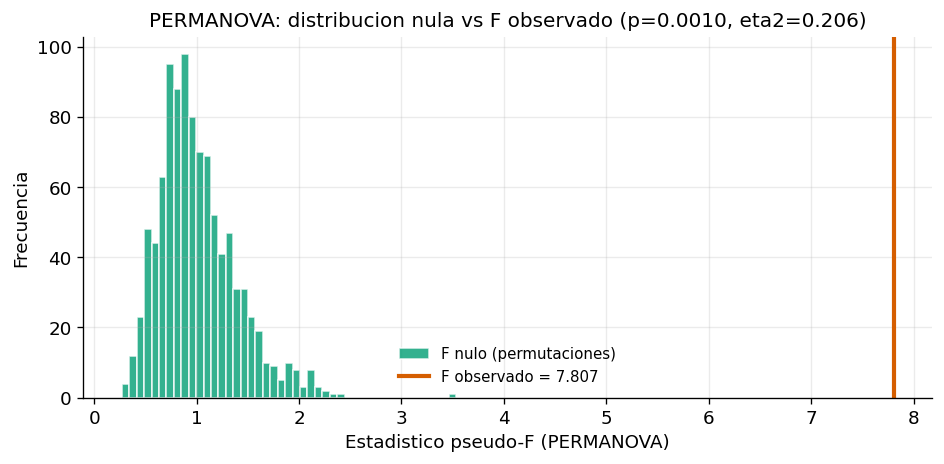


PERMANOVA pairwise (Bonferroni, 499 permutaciones por par):


,Par,F,p,p (Bonferroni),eta2,Sig.
0,VA32D vs VC30D,20.247,0.002,0.012,0.232,*
1,VA32D vs VC94C,3.730,0.008,0.048,0.114,*
2,VA32D vs WZ72B,6.443,0.004,0.024,0.227,*
3,VC30D vs VC94C,4.099,0.004,0.024,0.057,*
4,VC30D vs WZ72B,5.050,0.002,0.012,0.076,*
5,VC94C vs WZ72B,1.612,0.172,1.000,0.065,


In [32]:
def permanova_f(X, group_labels, n_perm=999, rng=None):
    # Pseudo-F de Anderson sobre distancia euclidiana
    if rng is None:
        rng = np.random.default_rng(tb.SEED)
    D2 = squareform(pdist(X, metric='euclidean')) ** 2
    n  = len(group_labels)
    unique_g = np.unique(group_labels)
    k = len(unique_g)

    def fstat(labs):
        SS_T = D2.sum() / (2 * n)
        SS_W = sum(
            D2[np.ix_(labs == g, labs == g)].sum() / (2 * np.sum(labs == g))
            for g in unique_g if np.sum(labs == g) >= 2
        )
        SS_A = SS_T - SS_W
        return (SS_A / (k - 1)) / (SS_W / (n - k)) if SS_W > 0 else np.inf

    F_obs  = fstat(group_labels)
    F_null = np.array([fstat(rng.permutation(group_labels)) for _ in range(n_perm)])
    p_val  = (np.sum(F_null >= F_obs) + 1) / (n_perm + 1)
    eta_sq = (F_obs * (k - 1)) / (F_obs * (k - 1) + (n - k))
    return F_obs, p_val, eta_sq, F_null

print('PERMANOVA global (999 permutaciones) ...')
F_obs, p_perm, eta_sq, F_null = permanova_f(X_sc, grp)
print(f'\n  F observado          = {F_obs:.3f}')
print(f'  p-valor (permut.)    = {p_perm:.4f}')
print(f'  eta2 (tamaño efecto) = {eta_sq:.3f}')
interp_eta = ('grande' if eta_sq > 0.14 else 'mediano' if eta_sq > 0.06 else 'pequeño')
print(f'  Interpretacion eta2:   {interp_eta} (>0.14 grande, 0.06-0.14 mediano, <0.06 pequeño)')
if p_perm < 0.05:
    print('\n  Las explotaciones son grupos SIGNIFICATIVAMENTE distintos (alfa=0.05).')
else:
    print('\n  No se detecta separacion significativa (alfa=0.05).')

# Distribucion nula
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(F_null, bins=45, color=PALETTE[2], alpha=0.8, edgecolor='white',
        label='F nulo (permutaciones)')
ax.axvline(F_obs, color=PALETTE[1], lw=2.5,
           label=f'F observado = {F_obs:.3f}')
ax.set_xlabel('Estadistico pseudo-F (PERMANOVA)')
ax.set_ylabel('Frecuencia')
ax.set_title(f'PERMANOVA: distribucion nula vs F observado (p={p_perm:.4f}, eta2={eta_sq:.3f})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('figures/fig_05_permanova.png', dpi=150, bbox_inches='tight')
plt.show()

# Pairwise PERMANOVA + Bonferroni
print('\nPERMANOVA pairwise (Bonferroni, 499 permutaciones por par):')
pairs_perm = list(combinations(EXPLOTS, 2))
n_p = len(pairs_perm)
pw_rows = []
for a, b in pairs_perm:
    mask = np.isin(grp, [a, b])
    F_ab, p_ab, eta_ab, _ = permanova_f(X_sc[mask], grp[mask], n_perm=499)
    p_bonf = min(p_ab * n_p, 1.0)
    sig = '*' if p_bonf < 0.05 else ''
    pw_rows.append({
        'Par': f'{a} vs {b}',
        'F': round(F_ab, 3), 'p': round(p_ab, 4),
        'p (Bonferroni)': round(p_bonf, 4),
        'eta2': round(eta_ab, 3), 'Sig.': sig,
    })
display(pd.DataFrame(pw_rows))


## 17. Síntesis del análisis no supervisado

### Silhouette coefficient con etiquetas de explotación

Mide, para cada animal, si es más parecido a sus compañeros de explotación
que a los animales de otras granjas. Rango: −1 (mal agrupado) a 1 (perfecto).


Silhouette global (explotación como cluster): -0.006
  >0.50 → fuerte | 0.25-0.50 → moderado | 0-0.25 → débil | <0 → superpuesto

Silhouette medio por explotación:
  VA32D: 0.014  (n=15)
  VC30D: 0.013  (n=54)
  VC94C: -0.261  (n=16)
  WZ72B: 0.301  (n=9)


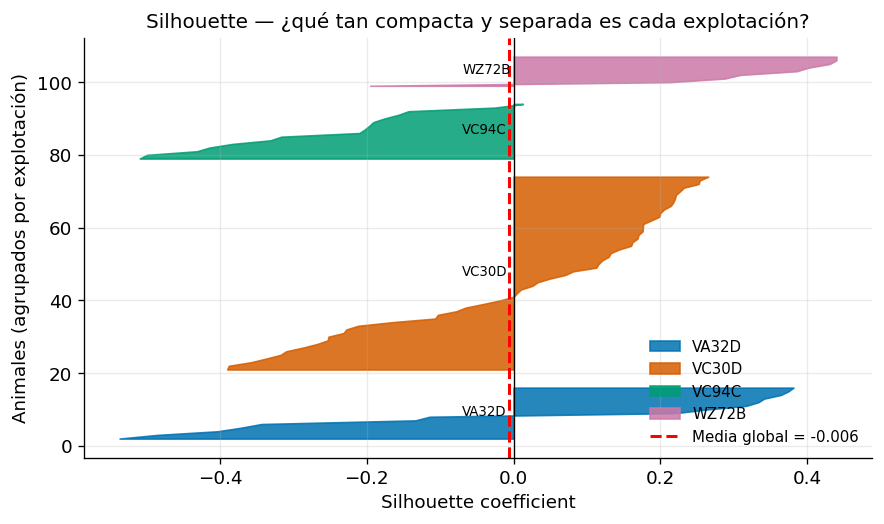


TABLA RESUMEN — ¿Es la explotación un factor estructurante?


,Análisis,Valor,Interpretación
0,Silhouette (explotación como cluster),-0.006,débil / solapamiento
1,k-means (k=4) — ARI vs explotación,0.104,bajo / aleatorio
2,k-means (k=4) — NMI vs explotación,0.224,"0=independiente, 1=idéntico"
3,k-means (k=4) — V-measure,0.224,homog. × completeness
4,PERMANOVA pseudo-F (p=0.0010),7.807,η²=0.206 (grande)
5,Varianza explicada PC1+PC2,53.8%,% varianza total en 2 dims


In [33]:
# ── Silhouette por explotación ─────────────────────────────────────────────
sil_global  = silhouette_score(X_sc, grp_num)
sil_samples = silhouette_samples(X_sc, grp_num)

print(f"Silhouette global (explotación como cluster): {sil_global:.3f}")
print(f"  >0.50 → fuerte | 0.25-0.50 → moderado | 0-0.25 → débil | <0 → superpuesto")
print()
print("Silhouette medio por explotación:")
for g in EXPLOTS:
    m = grp == g
    print(f"  {g}: {sil_samples[m].mean():.3f}  (n={m.sum()})")

# Gráfico silhouette
fig, ax = plt.subplots(figsize=(7.5, 4.5))
y_lower = 2
for g in EXPLOTS:
    m = grp == g
    vals = np.sort(sil_samples[m])
    y_upper = y_lower + vals.shape[0]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     alpha=0.85, color=EXPL_COLORS[g], label=g)
    ax.text(-0.07, (y_lower + y_upper) / 2, g, fontsize=8, va="center", color="black")
    y_lower = y_upper + 4

ax.axvline(sil_global, color="red", lw=1.8, ls="--",
           label=f"Media global = {sil_global:.3f}")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Animales (agrupados por explotación)")
ax.set_title("Silhouette — ¿qué tan compacta y separada es cada explotación?")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig("figures/fig_05_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Tabla resumen de todos los análisis no supervisados ───────────────────────
print()
print("=" * 68)
print("TABLA RESUMEN — ¿Es la explotación un factor estructurante?")
print("=" * 68)
interp_sil = ("fuerte" if sil_global > 0.5
              else "moderado" if sil_global > 0.25
              else "débil / solapamiento")
interp_ari = ("alto" if ari_km > 0.5
              else "moderado" if ari_km > 0.25
              else "bajo / aleatorio")
interp_eta = ("grande" if eta_sq > 0.14
              else "mediano" if eta_sq > 0.06
              else "pequeño")
summary_clust = pd.DataFrame([
    {"Análisis": "Silhouette (explotación como cluster)",
     "Valor": f"{sil_global:.3f}", "Interpretación": interp_sil},
    {"Análisis": f"k-means (k={len(EXPLOTS)}) — ARI vs explotación",
     "Valor": f"{ari_km:.3f}", "Interpretación": interp_ari},
    {"Análisis": f"k-means (k={len(EXPLOTS)}) — NMI vs explotación",
     "Valor": f"{nmi_km:.3f}", "Interpretación": "0=independiente, 1=idéntico"},
    {"Análisis": f"k-means (k={len(EXPLOTS)}) — V-measure",
     "Valor": f"{vm_km:.3f}", "Interpretación": "homog. × completeness"},
    {"Análisis": f"PERMANOVA pseudo-F (p={p_perm:.4f})",
     "Valor": f"{F_obs:.3f}", "Interpretación": f"η²={eta_sq:.3f} ({interp_eta})"},
    {"Análisis": "Varianza explicada PC1+PC2",
     "Valor": f"{(var[0]+var[1]):.1%}", "Interpretación": "% varianza total en 2 dims"},
])
display(summary_clust)


## 10. Conclusiones descriptivas

*(Completar con los resultados obtenidos al ejecutar el notebook)*

### Prevalencia de lesiones
- Indicar si las prevalencias difieren significativamente entre explotaciones
  (resultado del test chi-cuadrado global y pares significativos).
- Señalar qué explotación muestra mayor/menor prevalencia y su IC 95%.

### Gravedad (Score lesional)
- Indicar si el score lesional difiere entre explotaciones (Kruskal-Wallis).
- Señalar qué pares son significativos tras corrección de Bonferroni.
- Distinguir si la diferencia persiste cuando el análisis se restringe a TB+
  (efecto sobre la gravedad, no solo sobre la prevalencia).

### Patrón de lesiones
- Indicar si la proporción de patrón generalizado vs focal varía entre explotaciones.

### IDTC
- Indicar si hay variación significativa entre explotaciones.

### Perfil de biomarcadores
- Señalar qué biomarcadores difieren significativamente por explotación.
- Comentar si la variación en VitD o calcio podría explicar parte de las diferencias
  de prevalencia (exploratoriamente; no implica causalidad).

---
> **Limitaciones:**
> - El diseño es transversal y observacional. Las diferencias entre explotaciones
>   pueden deberse a factores estructurales (tamaño del rebaño, manejo, contacto
>   fauna silvestre) no recogidos en los datos.
> - El tamaño de algunas explotaciones (n=14–16) limita la potencia estadística.
> - Las comparaciones pareadas no controlan cofactores como edad o raza.